# Activation Functions: A Complete Guide
## From Classical to Modern Neural Network Activations

---

### Table of Contents
1. [Introduction](#introduction)
2. [Classical Activation Functions](#classical)
   - Sigmoid
   - Tanh
   - ReLU
3. [ReLU Family](#relu-family)
   - Leaky ReLU
   - Parametric ReLU (PReLU)
   - Exponential Linear Unit (ELU)
   - Scaled ELU (SELU)
4. [Modern Activation Functions](#modern)
   - Swish / SiLU
   - GELU (Gaussian Error Linear Unit)
   - Mish
5. [Advanced Activations](#advanced)
   - Hermite Polynomial Activations
   - Learnable Activations (APL, PAU)
   - Adaptive Activations
6. [Comparative Analysis](#comparison)
7. [Use Cases & Best Practices](#use-cases)
8. [Summary](#summary)

---

<a id='introduction'></a>
## 1. Introduction

### What is an Activation Function?

An activation function determines the output of a neuron given its input. It introduces **non-linearity** into neural networks, enabling them to learn complex patterns.

**General form:**
$$a = f(z) = f(Wx + b)$$

where:
- $z$ is the pre-activation (linear combination)
- $f$ is the activation function
- $a$ is the activation (output)

### Why Non-linearity Matters

Without activation functions (or with linear activations), a neural network would be equivalent to a single-layer linear model, regardless of depth:

$$f(f(x)) = W_2(W_1 x + b_1) + b_2 = W_{combined}x + b_{combined}$$

**Key Properties of Good Activation Functions:**
1. **Non-linearity:** Enable learning complex patterns
2. **Differentiability:** Allow gradient-based optimization
3. **Computational efficiency:** Fast to compute
4. **Avoid saturation:** Prevent vanishing gradients
5. **Zero-centered:** Help with convergence
6. **Bounded or unbounded:** Depending on application

---

<a id='classical'></a>
## 2. Classical Activation Functions

These are the foundational activation functions that shaped early neural networks.

---

### 2.1 Sigmoid (Logistic Function)

**Mathematical Definition:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Derivative:**
$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

**Proof of Derivative:**

Let $\sigma(z) = \frac{1}{1 + e^{-z}} = (1 + e^{-z})^{-1}$

Using the chain rule:
$$\frac{d\sigma}{dz} = -(1 + e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^2}$$

Notice that:
$$\sigma(z)(1 - \sigma(z)) = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \frac{e^{-z}}{(1+e^{-z})^2}$$

Therefore: $\boxed{\sigma'(z) = \sigma(z)(1-\sigma(z))}$

**Properties:**
- **Range:** $(0, 1)$
- **Zero-centered:** No (output is always positive)
- **Monotonic:** Yes (always increasing)
- **Differentiable:** Yes, everywhere

**Advantages:**
✅ Smooth gradient
✅ Output bounded between 0 and 1 (good for probabilities)
✅ Clear probabilistic interpretation

**Disadvantages:**
❌ **Vanishing gradient problem:** For large $|z|$, gradient approaches zero
❌ **Not zero-centered:** Can slow down convergence
❌ **Computationally expensive:** Exponential operation

**Use Cases:**
- Binary classification (output layer)
- Gating mechanisms (LSTM, GRU)
- Legacy networks (less common in hidden layers now)

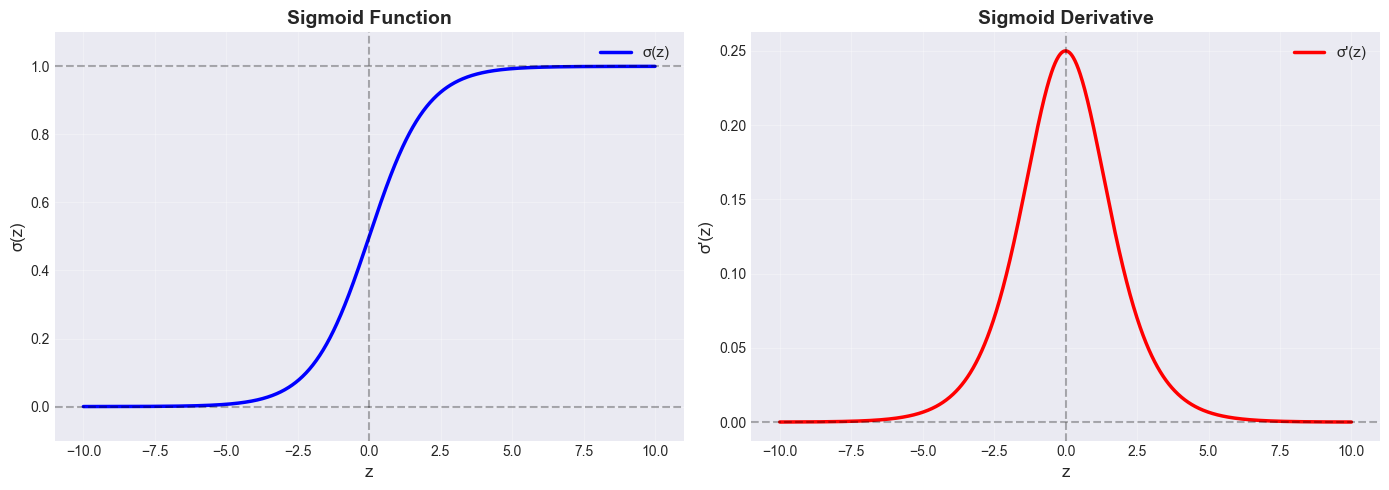

Key observations:
- Maximum derivative: 0.2500 at z=0
- At z=±5: derivative ≈ 0.006648 (vanishing gradient!)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Setup for high-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Sigmoid function and derivative
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    """Derivative of sigmoid."""
    s = sigmoid(z)
    return s * (1 - s)

# Plot
z = np.linspace(-10, 10, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Function
ax1.plot(z, sigmoid(z), 'b-', linewidth=2.5, label='σ(z)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('σ(z)', fontsize=12)
ax1.set_title('Sigmoid Function', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim([-0.1, 1.1])

# Derivative
ax2.plot(z, sigmoid_derivative(z), 'r-', linewidth=2.5, label="σ'(z)")
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("σ'(z)", fontsize=12)
ax2.set_title('Sigmoid Derivative', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Maximum derivative: {np.max(sigmoid_derivative(z)):.4f} at z=0")
print(f"- At z=±5: derivative ≈ {sigmoid_derivative(5):.6f} (vanishing gradient!)")

### 2.2 Hyperbolic Tangent (Tanh)

**Mathematical Definition:**
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = \frac{e^{2z} - 1}{e^{2z} + 1}$$

**Alternative form:**
$$\tanh(z) = 2\sigma(2z) - 1$$

This shows tanh is a scaled and shifted sigmoid!

**Derivative:**
$$\tanh'(z) = 1 - \tanh^2(z)$$

**Proof of Derivative:**

Using quotient rule on $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$:

$$\frac{d}{dz}\tanh(z) = \frac{(e^z + e^{-z})(e^z + e^{-z}) - (e^z - e^{-z})(e^z - e^{-z})}{(e^z + e^{-z})^2}$$

$$= \frac{(e^z + e^{-z})^2 - (e^z - e^{-z})^2}{(e^z + e^{-z})^2}$$

$$= 1 - \frac{(e^z - e^{-z})^2}{(e^z + e^{-z})^2} = 1 - \tanh^2(z)$$

Therefore: $\boxed{\tanh'(z) = 1 - \tanh^2(z)}$

**Properties:**
- **Range:** $(-1, 1)$
- **Zero-centered:** Yes! (unlike sigmoid)
- **Monotonic:** Yes (always increasing)
- **Differentiable:** Yes, everywhere

**Advantages:**
✅ **Zero-centered:** Better than sigmoid for hidden layers
✅ Stronger gradients than sigmoid (derivative up to 1)
✅ Smooth and differentiable

**Disadvantages:**
❌ Still suffers from vanishing gradients
❌ Computationally expensive (exponentials)

**Use Cases:**
- Hidden layers (when ReLU doesn't work well)
- Recurrent neural networks (LSTM, GRU)
- When you need outputs in range $[-1, 1]$

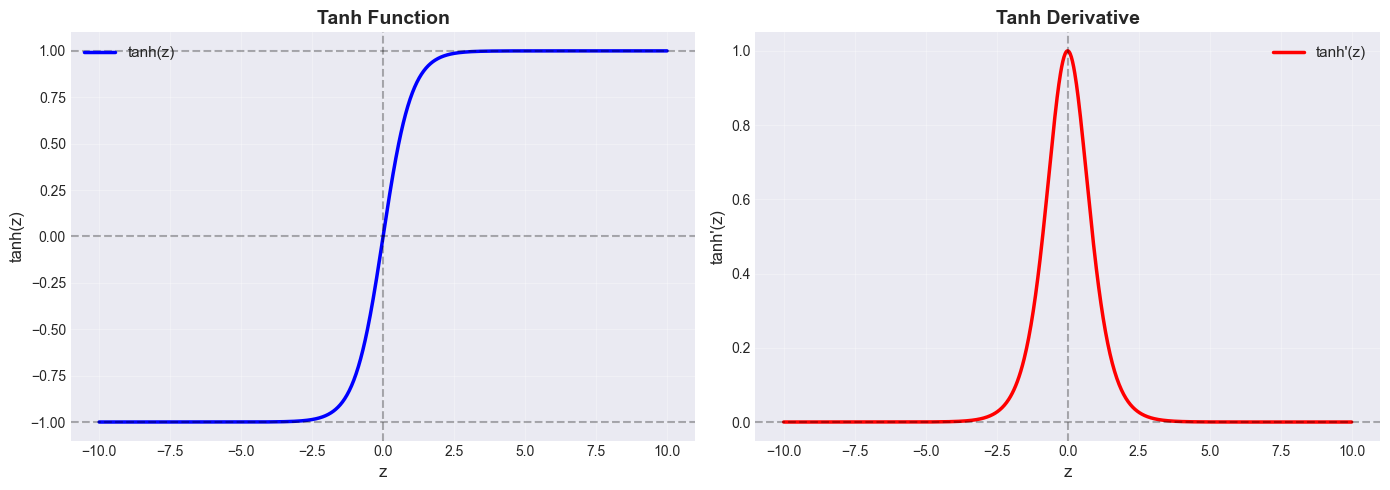

Key observations:
- Maximum derivative: 0.9999 at z=0
- At z=±3: derivative ≈ 0.009866
- Zero-centered: ✓ (tanh(0) = 0.0)


In [2]:
# Tanh function and derivative
def tanh(z):
    """Tanh activation function."""
    return np.tanh(z)

def tanh_derivative(z):
    """Derivative of tanh."""
    t = np.tanh(z)
    return 1 - t**2

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Function
ax1.plot(z, tanh(z), 'b-', linewidth=2.5, label='tanh(z)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax1.axhline(y=-1, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('tanh(z)', fontsize=12)
ax1.set_title('Tanh Function', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim([-1.1, 1.1])

# Derivative
ax2.plot(z, tanh_derivative(z), 'r-', linewidth=2.5, label="tanh'(z)")
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("tanh'(z)", fontsize=12)
ax2.set_title('Tanh Derivative', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Maximum derivative: {np.max(tanh_derivative(z)):.4f} at z=0")
print(f"- At z=±3: derivative ≈ {tanh_derivative(3):.6f}")
print(f"- Zero-centered: ✓ (tanh(0) = {tanh(0):.1f})")

### 2.3 ReLU (Rectified Linear Unit)

**Mathematical Definition:**
$$\text{ReLU}(z) = \max(0, z) = \begin{cases} 
z & \text{if } z > 0 \\
0 & \text{if } z \leq 0
\end{cases}$$

**Derivative:**
$$\text{ReLU}'(z) = \begin{cases} 
1 & \text{if } z > 0 \\
0 & \text{if } z < 0 \\
\text{undefined} & \text{if } z = 0
\end{cases}$$

In practice, we often set the derivative at $z=0$ to be 0 or 1.

**Properties:**
- **Range:** $[0, \infty)$
- **Zero-centered:** No
- **Monotonic:** Yes (non-decreasing)
- **Differentiable:** Almost everywhere (not at $z=0$)

**Advantages:**
✅ **No vanishing gradient problem** for positive inputs
✅ **Computationally efficient:** Simple max operation
✅ **Sparse activation:** Many neurons output zero (useful for interpretability)
✅ **Empirically works very well** in deep networks

**Disadvantages:**
❌ **Dying ReLU problem:** Neurons can "die" (always output 0)
❌ **Not zero-centered:** Can slow convergence
❌ **Unbounded:** Can lead to exploding activations

**Use Cases:**
- **Default choice** for hidden layers in deep networks
- Convolutional neural networks (CNNs)
- Most modern architectures (ResNet, VGG, etc.)

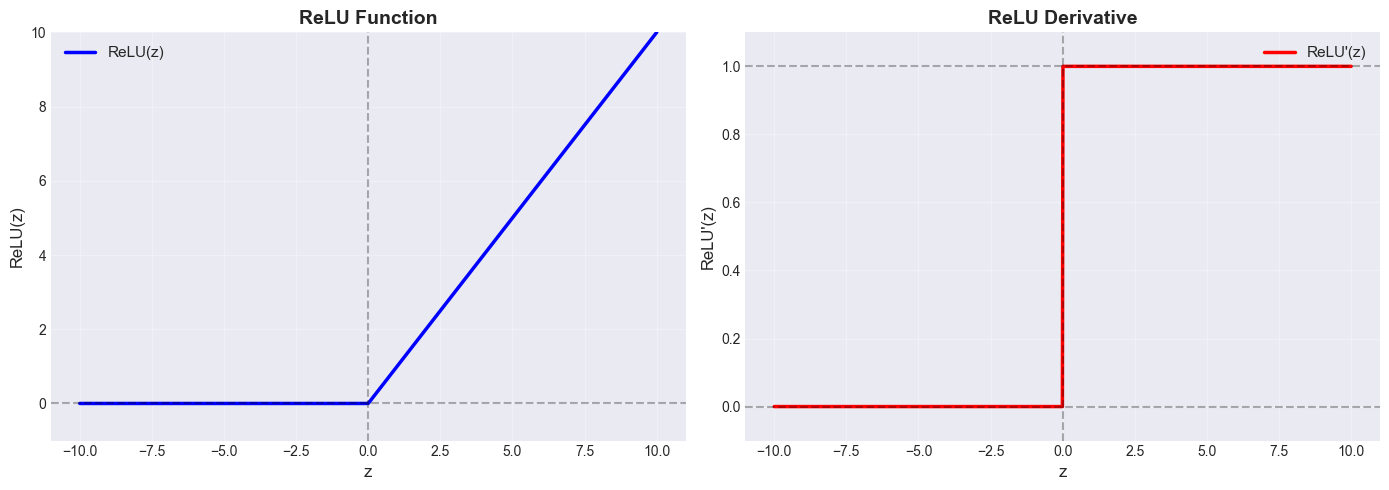

Key observations:
- Derivative is constant (1) for z > 0: No vanishing gradient!
- Derivative is 0 for z < 0: Can lead to dead neurons
- Computational cost: Minimal (just comparison and max)


In [3]:
# ReLU function and derivative
def relu(z):
    """ReLU activation function."""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU."""
    return (z > 0).astype(float)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Function
ax1.plot(z, relu(z), 'b-', linewidth=2.5, label='ReLU(z)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('ReLU(z)', fontsize=12)
ax1.set_title('ReLU Function', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim([-1, 10])

# Derivative
ax2.plot(z, relu_derivative(z), 'r-', linewidth=2.5, label="ReLU'(z)")
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("ReLU'(z)", fontsize=12)
ax2.set_title('ReLU Derivative', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Derivative is constant (1) for z > 0: No vanishing gradient!")
print(f"- Derivative is 0 for z < 0: Can lead to dead neurons")
print(f"- Computational cost: Minimal (just comparison and max)")

### Comparison: Sigmoid vs Tanh vs ReLU

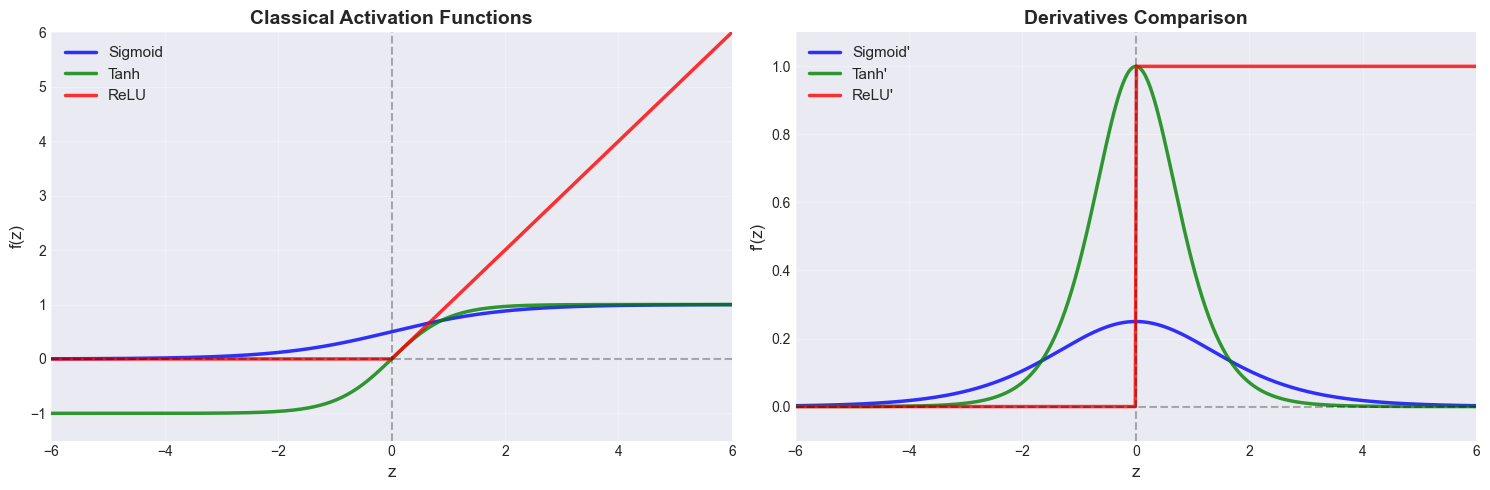


CLASSICAL ACTIVATIONS COMPARISON
Property             Sigmoid         Tanh            ReLU           
----------------------------------------------------------------------
Range                (0, 1)          (-1, 1)         [0, ∞)         
Zero-centered        No              Yes             No             
Max gradient         0.25            1.0             1.0            
Vanishing gradient   Yes             Yes             No (z>0)       
Computational cost   High            High            Low            
Common use           Output layer    RNN/LSTM        Hidden layers  


In [4]:
# Compare all three classical activations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Functions
ax1.plot(z, sigmoid(z), 'b-', linewidth=2.5, label='Sigmoid', alpha=0.8)
ax1.plot(z, tanh(z), 'g-', linewidth=2.5, label='Tanh', alpha=0.8)
ax1.plot(z, relu(z), 'r-', linewidth=2.5, label='ReLU', alpha=0.8)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('f(z)', fontsize=12)
ax1.set_title('Classical Activation Functions', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim([-1.5, 6])
ax1.set_xlim([-6, 6])

# Derivatives
ax2.plot(z, sigmoid_derivative(z), 'b-', linewidth=2.5, label="Sigmoid'", alpha=0.8)
ax2.plot(z, tanh_derivative(z), 'g-', linewidth=2.5, label="Tanh'", alpha=0.8)
ax2.plot(z, relu_derivative(z), 'r-', linewidth=2.5, label="ReLU'", alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("f'(z)", fontsize=12)
ax2.set_title('Derivatives Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([-0.1, 1.1])
ax2.set_xlim([-6, 6])

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("CLASSICAL ACTIVATIONS COMPARISON")
print("="*70)
print(f"{'Property':<20} {'Sigmoid':<15} {'Tanh':<15} {'ReLU':<15}")
print("-"*70)
print(f"{'Range':<20} {'(0, 1)':<15} {'(-1, 1)':<15} {'[0, ∞)':<15}")
print(f"{'Zero-centered':<20} {'No':<15} {'Yes':<15} {'No':<15}")
print(f"{'Max gradient':<20} {'0.25':<15} {'1.0':<15} {'1.0':<15}")
print(f"{'Vanishing gradient':<20} {'Yes':<15} {'Yes':<15} {'No (z>0)':<15}")
print(f"{'Computational cost':<20} {'High':<15} {'High':<15} {'Low':<15}")
print(f"{'Common use':<20} {'Output layer':<15} {'RNN/LSTM':<15} {'Hidden layers':<15}")
print("="*70)

<a id='relu-family'></a>
## 3. ReLU Family: Addressing ReLU Limitations

ReLU revolutionized deep learning, but it has issues. The ReLU family addresses these problems.

---

### 3.1 Leaky ReLU

**Mathematical Definition:**
$$\text{LeakyReLU}(z) = \max(\alpha z, z) = \begin{cases} 
z & \text{if } z > 0 \\
\alpha z & \text{if } z \leq 0
\end{cases}$$

where $\alpha$ is a small constant (typically 0.01).

**Derivative:**
$$\text{LeakyReLU}'(z) = \begin{cases} 
1 & \text{if } z > 0 \\
\alpha & \text{if } z \leq 0
\end{cases}$$

**Properties:**
- **Range:** $(-\infty, \infty)$
- **Fixes dying ReLU:** Always has a gradient
- **Parameter:** $\alpha$ (typically 0.01)

**Advantages:**
✅ **Prevents dying ReLU:** Negative gradients still backpropagate
✅ All ReLU benefits retained
✅ Simple and efficient

**Disadvantages:**
❌ Performance not always better than ReLU
❌ Introduces hyperparameter $\alpha$

**Use Cases:**
- When experiencing dying ReLU problem
- Deep networks with many layers
- Alternative to standard ReLU in CNNs

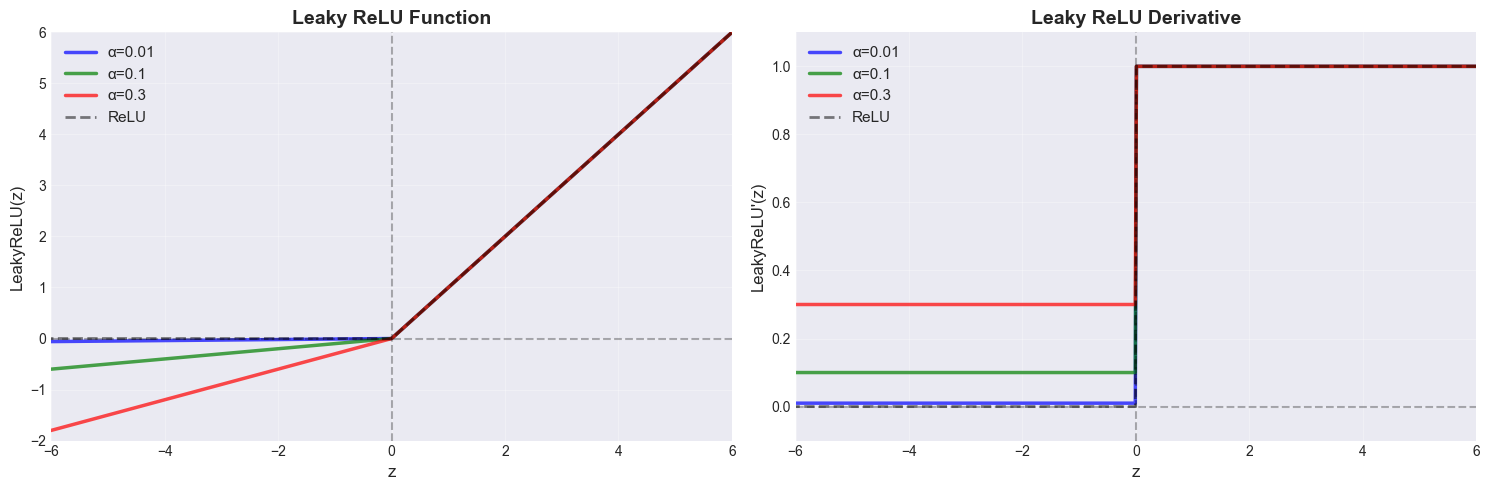

Key observations:
- Non-zero gradient for negative inputs prevents dying neurons
- Larger α allows more negative signal to pass through
- α=0.01 is most common in practice


In [5]:
# Leaky ReLU
def leaky_relu(z, alpha=0.01):
    """Leaky ReLU activation function."""
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    """Derivative of Leaky ReLU."""
    return np.where(z > 0, 1, alpha)

# Plot with different alpha values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

alphas = [0.01, 0.1, 0.3]
colors = ['blue', 'green', 'red']

for alpha, color in zip(alphas, colors):
    # Function
    ax1.plot(z, leaky_relu(z, alpha), linewidth=2.5, 
            label=f'α={alpha}', color=color, alpha=0.7)
    
    # Derivative
    ax2.plot(z, leaky_relu_derivative(z, alpha), linewidth=2.5, 
            label=f"α={alpha}", color=color, alpha=0.7)

# Regular ReLU for comparison
ax1.plot(z, relu(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)
ax2.plot(z, relu_derivative(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)

for ax in [ax1, ax2]:
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('z', fontsize=12)
    ax.legend(fontsize=11)

ax1.set_ylabel('LeakyReLU(z)', fontsize=12)
ax1.set_title('Leaky ReLU Function', fontsize=14, fontweight='bold')
ax1.set_ylim([-2, 6])
ax1.set_xlim([-6, 6])

ax2.set_ylabel("LeakyReLU'(z)", fontsize=12)
ax2.set_title('Leaky ReLU Derivative', fontsize=14, fontweight='bold')
ax2.set_ylim([-0.1, 1.1])
ax2.set_xlim([-6, 6])

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Non-zero gradient for negative inputs prevents dying neurons")
print(f"- Larger α allows more negative signal to pass through")
print(f"- α=0.01 is most common in practice")

### 3.2 Parametric ReLU (PReLU)

**Mathematical Definition:**
$$\text{PReLU}(z) = \max(\alpha z, z) = \begin{cases} 
z & \text{if } z > 0 \\
\alpha z & \text{if } z \leq 0
\end{cases}$$

**Key difference from Leaky ReLU:** $\alpha$ is a **learnable parameter** updated via backpropagation!

**Derivative w.r.t. $z$:**
$$\frac{\partial \text{PReLU}}{\partial z} = \begin{cases} 
1 & \text{if } z > 0 \\
\alpha & \text{if } z \leq 0
\end{cases}$$

**Derivative w.r.t. $\alpha$ (for learning $\alpha$):**
$$\frac{\partial \text{PReLU}}{\partial \alpha} = \begin{cases} 
0 & \text{if } z > 0 \\
z & \text{if } z \leq 0
\end{cases}$$

**Learning Rule:**
Given loss $L$ and using chain rule:
$$\frac{\partial L}{\partial \alpha} = \sum_{z < 0} \frac{\partial L}{\partial \text{PReLU}(z)} \cdot z$$

**Advantages:**
✅ **Adaptive:** Network learns optimal negative slope
✅ **Channel-specific:** Can have different $\alpha$ per channel
✅ Shown to improve performance on ImageNet

**Disadvantages:**
❌ Additional parameters to learn
❌ Risk of overfitting on small datasets

**Use Cases:**
- Large-scale image classification (ImageNet)
- When you have sufficient data
- ResNet-style architectures

PReLU Learning Demonstration
Initial α: 0.0100
Final α after training: 0.0253
Change: +0.0153


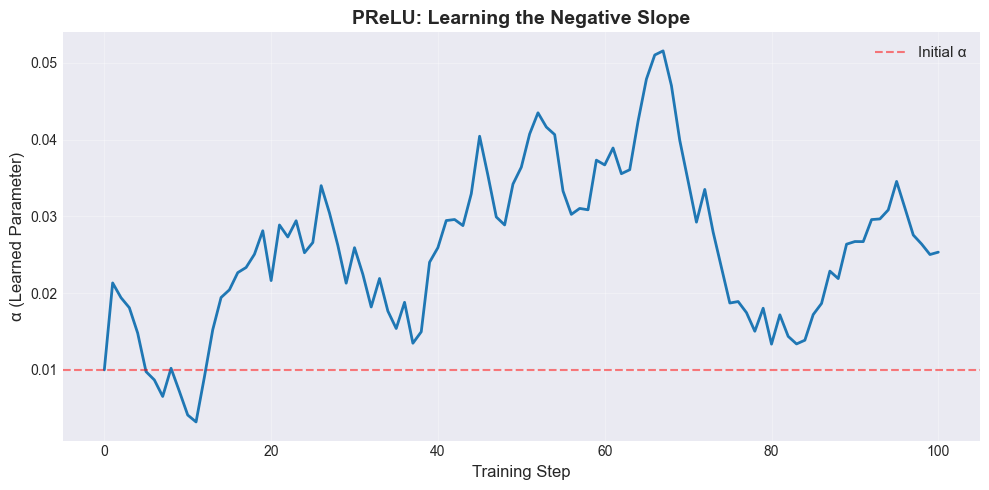

In [6]:
# PReLU implementation with learnable parameter
class PReLU:
    """Parametric ReLU with learnable alpha."""
    
    def __init__(self, alpha_init=0.25):
        self.alpha = alpha_init
        self.z_cache = None
    
    def forward(self, z):
        """Forward pass."""
        self.z_cache = z
        return np.where(z > 0, z, self.alpha * z)
    
    def backward(self, grad_output, learning_rate=0.01):
        """Backward pass - update alpha and return gradient."""
        # Gradient w.r.t. z
        grad_z = np.where(self.z_cache > 0, 1, self.alpha)
        
        # Gradient w.r.t. alpha
        grad_alpha = np.sum(grad_output * np.where(self.z_cache < 0, self.z_cache, 0))
        
        # Update alpha
        self.alpha -= learning_rate * grad_alpha
        
        return grad_output * grad_z

# Demonstrate learning behavior
np.random.seed(42)
prelu = PReLU(alpha_init=0.01)

print("PReLU Learning Demonstration")
print("="*50)
print(f"Initial α: {prelu.alpha:.4f}")

# Simulate training with negative-heavy data
z_sample = np.random.randn(1000) - 1  # Biased towards negative values
alpha_history = [prelu.alpha]

for epoch in range(100):
    output = prelu.forward(z_sample)
    # Fake gradient (in real training, this comes from loss)
    fake_grad = np.random.randn(1000)
    prelu.backward(fake_grad, learning_rate=0.0001)
    alpha_history.append(prelu.alpha)

print(f"Final α after training: {prelu.alpha:.4f}")
print(f"Change: {prelu.alpha - 0.01:+.4f}")

# Plot alpha evolution
plt.figure(figsize=(10, 5))
plt.plot(alpha_history, linewidth=2)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('α (Learned Parameter)', fontsize=12)
plt.title('PReLU: Learning the Negative Slope', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.01, color='r', linestyle='--', alpha=0.5, label='Initial α')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 3.3 Exponential Linear Unit (ELU)

**Mathematical Definition:**
$$\text{ELU}(z; \alpha) = \begin{cases} 
z & \text{if } z > 0 \\
\alpha(e^z - 1) & \text{if } z \leq 0
\end{cases}$$

where $\alpha > 0$ (typically $\alpha = 1$).

**Derivative:**
$$\text{ELU}'(z; \alpha) = \begin{cases} 
1 & \text{if } z > 0 \\
\alpha e^z = \text{ELU}(z) + \alpha & \text{if } z \leq 0
\end{cases}$$

**Properties:**
- **Range:** $(-\alpha, \infty)$
- **Smooth:** Unlike ReLU, it's smooth everywhere
- **Negative saturation:** Approaches $-\alpha$ as $z \to -\infty$

**Advantages:**
✅ **Smooth function:** Better gradient flow
✅ **Negative values:** Can push mean activation closer to zero
✅ **Self-normalizing:** Helps stabilize training (with SELU variant)
✅ **Robustness to noise**

**Disadvantages:**
❌ **Computational cost:** Exponential function
❌ Slower than ReLU

**Use Cases:**
- When you need smooth activations
- Deep networks requiring stable gradients
- Self-normalizing neural networks (SNN)

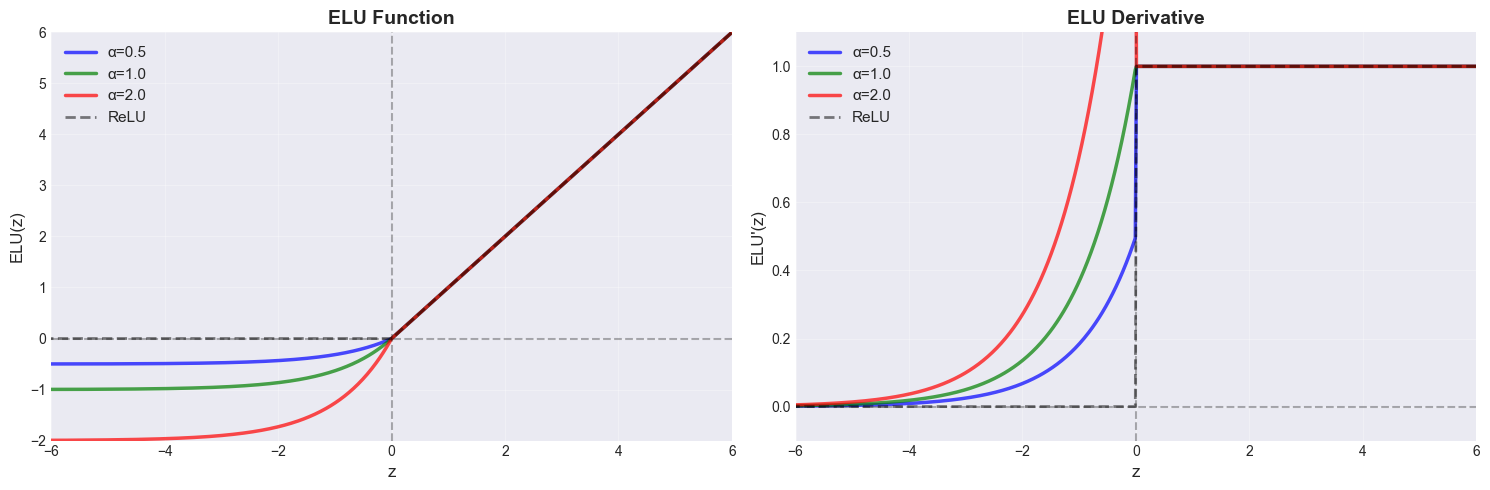

Key observations:
- Smooth everywhere (no kink at z=0)
- Saturates to -α for large negative values
- Derivative is smooth and continuous
- For z<0: ELU'(z) = ELU(z) + α


In [7]:
# ELU function and derivative
def elu(z, alpha=1.0):
    """ELU activation function."""
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def elu_derivative(z, alpha=1.0):
    """Derivative of ELU."""
    return np.where(z > 0, 1, alpha * np.exp(z))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Compare different alpha values
alphas = [0.5, 1.0, 2.0]
colors = ['blue', 'green', 'red']

for alpha, color in zip(alphas, colors):
    ax1.plot(z, elu(z, alpha), linewidth=2.5, 
            label=f'α={alpha}', color=color, alpha=0.7)
    ax2.plot(z, elu_derivative(z, alpha), linewidth=2.5, 
            label=f'α={alpha}', color=color, alpha=0.7)

# Add ReLU for comparison
ax1.plot(z, relu(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)
ax2.plot(z, relu_derivative(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)

for ax in [ax1, ax2]:
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('z', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_xlim([-6, 6])

ax1.set_ylabel('ELU(z)', fontsize=12)
ax1.set_title('ELU Function', fontsize=14, fontweight='bold')
ax1.set_ylim([-2, 6])

ax2.set_ylabel("ELU'(z)", fontsize=12)
ax2.set_title('ELU Derivative', fontsize=14, fontweight='bold')
ax2.set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Smooth everywhere (no kink at z=0)")
print(f"- Saturates to -α for large negative values")
print(f"- Derivative is smooth and continuous")
print(f"- For z<0: ELU'(z) = ELU(z) + α")

### 3.4 Scaled ELU (SELU)

**Mathematical Definition:**
$$\text{SELU}(z) = \lambda \begin{cases} 
z & \text{if } z > 0 \\
\alpha(e^z - 1) & \text{if } z \leq 0
\end{cases}$$

**Magic constants (derived mathematically):**
$$\lambda \approx 1.0507, \quad \alpha \approx 1.6733$$

**Derivative:**
$$\text{SELU}'(z) = \lambda \begin{cases} 
1 & \text{if } z > 0 \\
\alpha e^z & \text{if } z \leq 0
\end{cases}$$

**Self-Normalizing Property:**

SELU was specifically designed to create **Self-Normalizing Neural Networks (SNNs)**. Under certain conditions, it automatically keeps:
- Mean close to 0
- Variance close to 1

This happens through the **fixed point transformation** property:

Given inputs with mean 0 and variance 1, SELU preserves this distribution!

**Mathematical guarantee (from the paper):**

For properly initialized weights and certain network architectures, SELU activations converge to:
$$\mathbb{E}[a] \to 0, \quad \text{Var}[a] \to 1$$

This is achieved through the carefully chosen values of $\lambda$ and $\alpha$ that satisfy:
$$\lambda\left(\int_{-\infty}^{0} \alpha(e^x - 1) \phi(x)dx + \int_{0}^{\infty} x \phi(x)dx\right) = 0$$

where $\phi(x)$ is the standard normal PDF.

**Advantages:**
✅ **Self-normalizing:** No need for batch normalization
✅ **Faster convergence:** Due to automatic normalization
✅ **Cannot "die":** Unlike ReLU

**Disadvantages:**
❌ Requires specific initialization (LeCun normal)
❌ Works best with fully-connected networks
❌ Less effective with dropout or batch normalization

**Use Cases:**
- Fully-connected (dense) networks
- When avoiding batch normalization
- Self-Normalizing Neural Networks (SNNs)

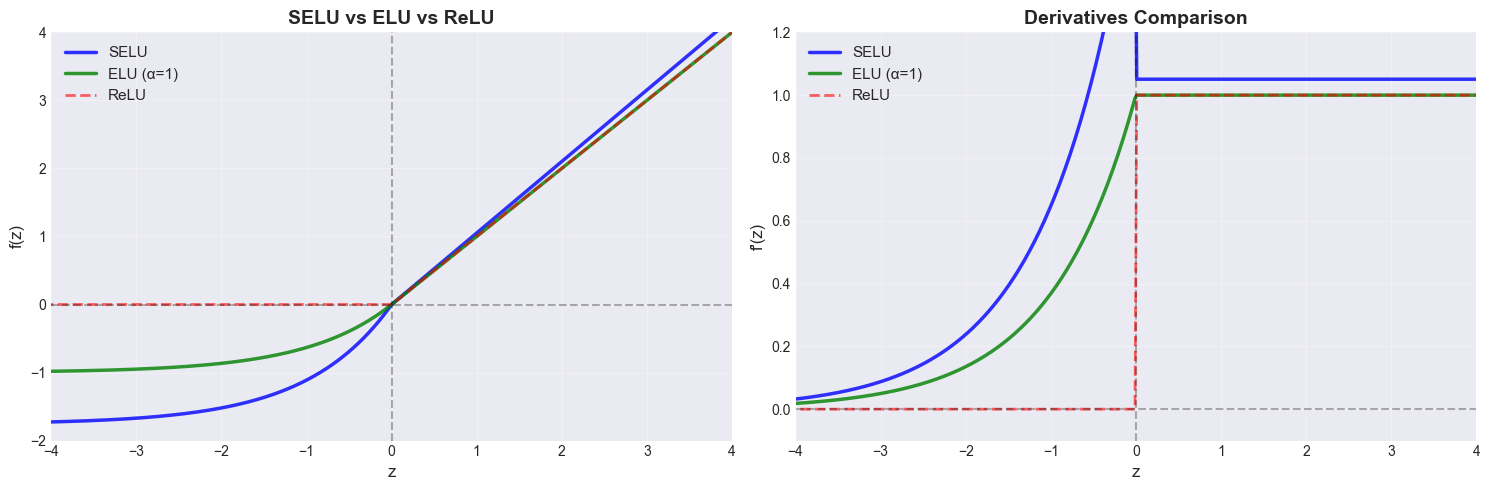


SELU Self-Normalizing Property Demonstration
Input statistics:
  Mean: -0.002136
  Variance: 1.006836

After SELU:
  Mean: -0.001486
  Variance: 1.004238


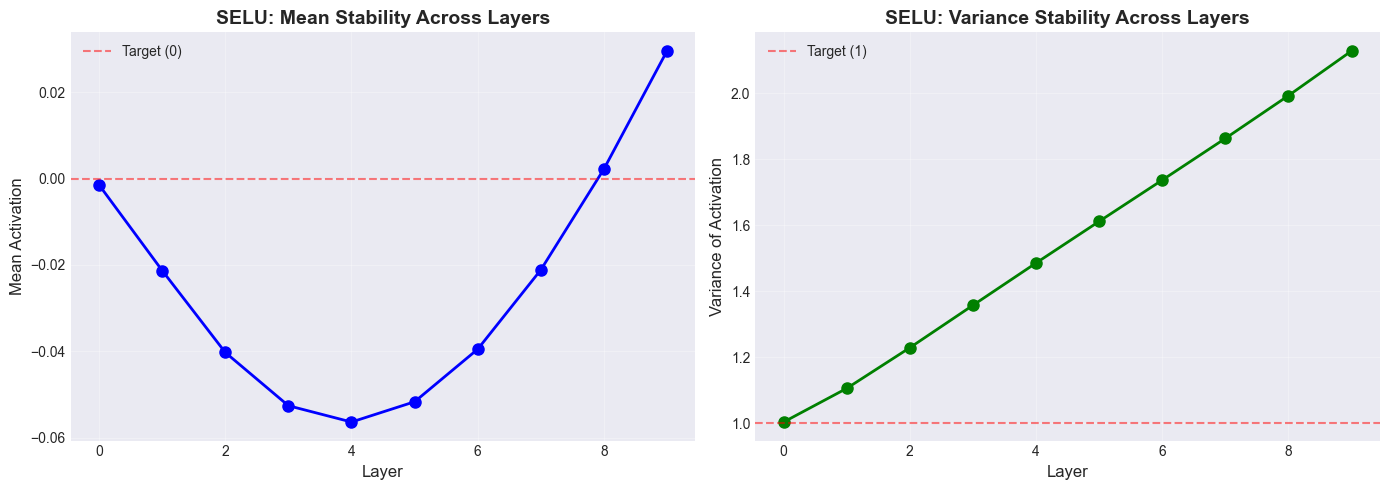


After 10 layers:
  Mean: 0.029540
  Variance: 2.128705
✓ Self-normalization maintained!


In [8]:
# SELU function
def selu(z):
    """SELU activation function."""
    alpha = 1.6732632423543772848170429916717
    scale = 1.0507009873554804934193349852946
    return scale * np.where(z > 0, z, alpha * (np.exp(z) - 1))

def selu_derivative(z):
    """Derivative of SELU."""
    alpha = 1.6732632423543772848170429916717
    scale = 1.0507009873554804934193349852946
    return scale * np.where(z > 0, 1, alpha * np.exp(z))

# Compare ELU and SELU
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(z, selu(z), 'b-', linewidth=2.5, label='SELU', alpha=0.8)
ax1.plot(z, elu(z, 1.0), 'g-', linewidth=2.5, label='ELU (α=1)', alpha=0.8)
ax1.plot(z, relu(z), 'r--', linewidth=2, label='ReLU', alpha=0.6)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('f(z)', fontsize=12)
ax1.set_title('SELU vs ELU vs ReLU', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xlim([-4, 4])
ax1.set_ylim([-2, 4])

ax2.plot(z, selu_derivative(z), 'b-', linewidth=2.5, label='SELU', alpha=0.8)
ax2.plot(z, elu_derivative(z, 1.0), 'g-', linewidth=2.5, label='ELU (α=1)', alpha=0.8)
ax2.plot(z, relu_derivative(z), 'r--', linewidth=2, label='ReLU', alpha=0.6)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("f'(z)", fontsize=12)
ax2.set_title('Derivatives Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_xlim([-4, 4])
ax2.set_ylim([-0.1, 1.2])

plt.tight_layout()
plt.show()

# Demonstrate self-normalizing property
print("\nSELU Self-Normalizing Property Demonstration")
print("="*60)

# Generate inputs with mean≈0, var≈1
np.random.seed(42)
n_samples = 10000
x = np.random.randn(n_samples)

print(f"Input statistics:")
print(f"  Mean: {np.mean(x):.6f}")
print(f"  Variance: {np.var(x):.6f}")

# Apply SELU
x_selu = selu(x)
print(f"\nAfter SELU:")
print(f"  Mean: {np.mean(x_selu):.6f}")
print(f"  Variance: {np.var(x_selu):.6f}")

# Apply multiple times (simulating layers)
x_layer = x
means, variances = [], []
for layer in range(10):
    x_layer = selu(x_layer)
    means.append(np.mean(x_layer))
    variances.append(np.var(x_layer))

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(10), means, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Target (0)')
ax1.set_xlabel('Layer', fontsize=12)
ax1.set_ylabel('Mean Activation', fontsize=12)
ax1.set_title('SELU: Mean Stability Across Layers', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(range(10), variances, 'go-', linewidth=2, markersize=8)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Target (1)')
ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Variance of Activation', fontsize=12)
ax2.set_title('SELU: Variance Stability Across Layers', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nAfter 10 layers:")
print(f"  Mean: {means[-1]:.6f}")
print(f"  Variance: {variances[-1]:.6f}")
print("✓ Self-normalization maintained!")

<a id='modern'></a>
## 4. Modern Activation Functions

Recent research has developed activations that combine the best properties of classical functions with new innovations.

---

### 4.1 Swish / SiLU (Sigmoid-weighted Linear Unit)

**Mathematical Definition:**
$$\text{Swish}(z) = z \cdot \sigma(z) = \frac{z}{1 + e^{-z}}$$

Also called **SiLU** (Sigmoid Linear Unit) or **Swish-1**.

**Parameterized version:**
$$\text{Swish}(z; \beta) = z \cdot \sigma(\beta z) = \frac{z}{1 + e^{-\beta z}}$$

**Derivative:**

Using product rule: $\frac{d}{dz}[z \cdot \sigma(z)]$

Let $f(z) = z$ and $g(z) = \sigma(z)$

$$\text{Swish}'(z) = \sigma(z) + z\sigma'(z)$$
$$= \sigma(z) + z\sigma(z)(1-\sigma(z))$$
$$= \sigma(z)[1 + z(1-\sigma(z))]$$
$$= \sigma(z)[1 + z - z\sigma(z)]$$

**Alternative form:**
$$\text{Swish}'(z) = \text{Swish}(z) + \sigma(z)(1 - \text{Swish}(z))$$

**Properties:**
- **Smooth and non-monotonic:** Unlike ReLU
- **Unbounded above, bounded below:** Similar to ReLU
- **Self-gating:** The function gates itself via sigmoid
- **Range:** $\approx (-0.28, \infty)$

**Key Insight:** 
Swish interpolates between linear function ($\beta \to 0$) and ReLU-like behavior ($\beta \to \infty$).

**Advantages:**
✅ **State-of-the-art performance:** Outperforms ReLU on many tasks
✅ **Smooth:** Better gradient flow than ReLU
✅ **Non-monotonic:** Can model more complex patterns
✅ **Adaptive:** Gates information flow

**Disadvantages:**
❌ More computationally expensive than ReLU
❌ Non-monotonic can be harder to analyze

**Use Cases:**
- **Modern deep networks** (EfficientNet, Transformer models)
- **Computer vision** (superior to ReLU in many cases)
- **NLP models** (BERT variants, GPT)

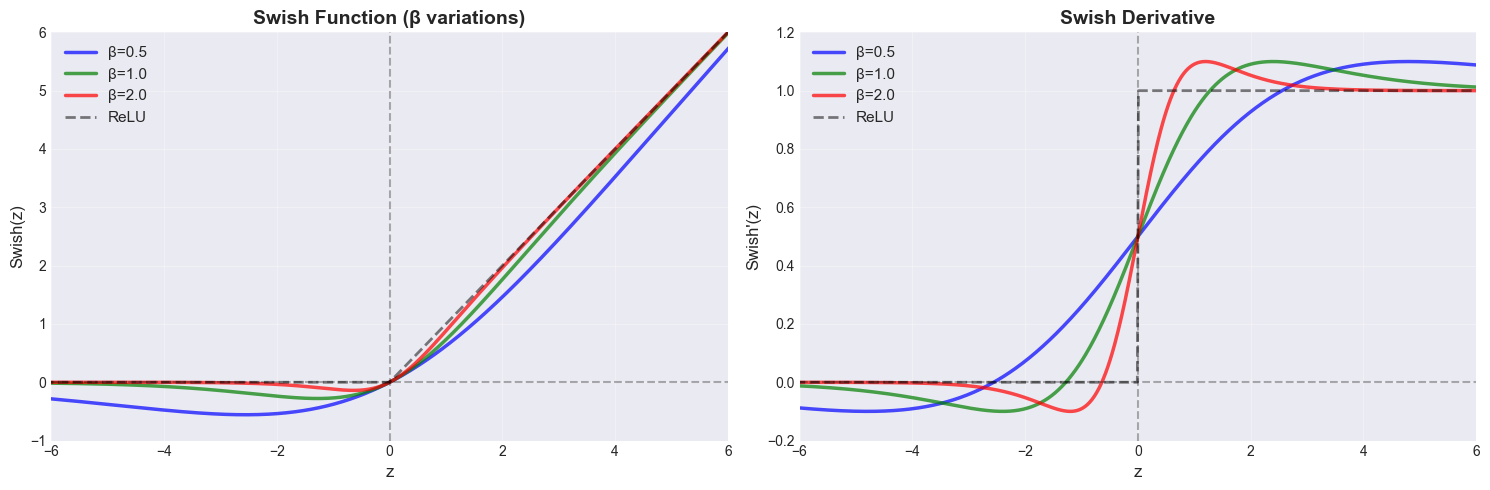

Key observations:
- Non-monotonic: has a small dip for negative z
- Minimum value ≈ -0.2785 at z ≈ -1.28
- Smooth everywhere (infinitely differentiable)
- Derivative can be > 1 for certain z values


In [9]:
# Swish / SiLU function
def swish(z, beta=1.0):
    """Swish activation function."""
    return z * sigmoid(beta * z)

def swish_derivative(z, beta=1.0):
    """Derivative of Swish."""
    sig = sigmoid(beta * z)
    return sig + beta * z * sig * (1 - sig)

# Plot with different beta values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

betas = [0.5, 1.0, 2.0]
colors = ['blue', 'green', 'red']

for beta, color in zip(betas, colors):
    ax1.plot(z, swish(z, beta), linewidth=2.5, 
            label=f'β={beta}', color=color, alpha=0.7)
    ax2.plot(z, swish_derivative(z, beta), linewidth=2.5, 
            label=f'β={beta}', color=color, alpha=0.7)

# Add ReLU for comparison
ax1.plot(z, relu(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)
ax2.plot(z, relu_derivative(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)

for ax in [ax1, ax2]:
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('z', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_xlim([-6, 6])

ax1.set_ylabel('Swish(z)', fontsize=12)
ax1.set_title('Swish Function (β variations)', fontsize=14, fontweight='bold')
ax1.set_ylim([-1, 6])

ax2.set_ylabel("Swish'(z)", fontsize=12)
ax2.set_title('Swish Derivative', fontsize=14, fontweight='bold')
ax2.set_ylim([-0.2, 1.2])

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Non-monotonic: has a small dip for negative z")
print(f"- Minimum value ≈ {np.min(swish(z, 1.0)):.4f} at z ≈ -1.28")
print(f"- Smooth everywhere (infinitely differentiable)")
print(f"- Derivative can be > 1 for certain z values")

### 4.2 GELU (Gaussian Error Linear Unit)

**Mathematical Definition:**

GELU uses the **cumulative distribution function (CDF)** of the standard normal distribution:

$$\text{GELU}(z) = z \cdot \Phi(z)$$

where $\Phi(z) = P(X \leq z)$ for $X \sim \mathcal{N}(0, 1)$ is:

$$\Phi(z) = \frac{1}{2}\left[1 + \text{erf}\left(\frac{z}{\sqrt{2}}\right)\right]$$

and $\text{erf}$ is the error function:
$$\text{erf}(z) = \frac{2}{\sqrt{\pi}}\int_0^z e^{-t^2}dt$$

**Approximation (faster computation):**

$$\text{GELU}(z) \approx 0.5z\left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}\left(z + 0.044715z^3\right)\right]\right)$$

**Another approximation (sigmoid-based):**
$$\text{GELU}(z) \approx z \cdot \sigma(1.702z)$$

**Derivative:**

$$\text{GELU}'(z) = \Phi(z) + z \cdot \phi(z)$$

where $\phi(z) = \frac{1}{\sqrt{2\pi}}e^{-z^2/2}$ is the standard normal PDF.

**Intuition:**

GELU can be viewed as a **stochastic regularizer:**
- Randomly drops inputs based on their magnitude
- Inputs with smaller magnitude have higher probability of being dropped
- Smoother than ReLU dropout

**Properties:**
- **Smooth:** Infinitely differentiable
- **Non-monotonic:** Like Swish
- **Probabilistic interpretation:** Gates based on normal distribution

**Advantages:**
✅ **State-of-the-art NLP:** Used in BERT, GPT-2, GPT-3
✅ **Smoother than ReLU:** Better gradient flow
✅ **Regularization effect:** Built-in stochastic regularization

**Disadvantages:**
❌ **Computational cost:** CDF/erf more expensive than ReLU
❌ Approximations needed for speed

**Use Cases:**
- **Transformers** (BERT, GPT, T5)
- **Modern NLP models**
- **Vision Transformers** (ViT)
- **When you need smooth, probabilistic gating**

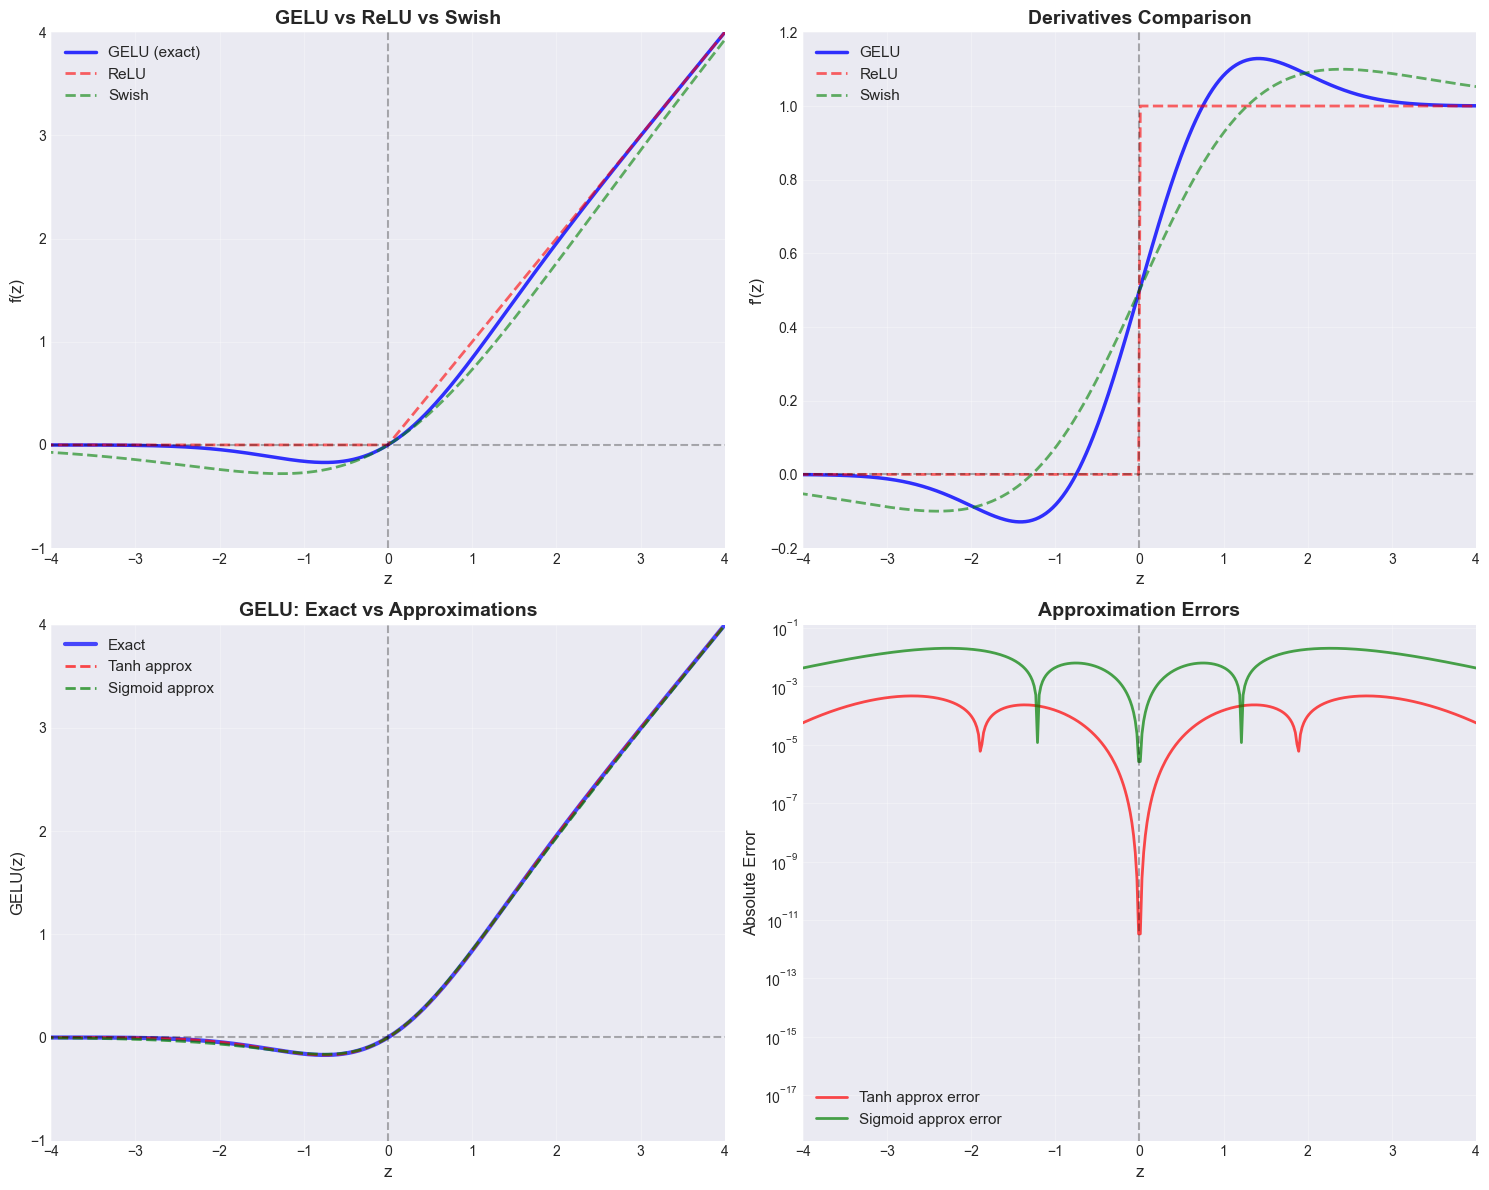

GELU Statistics:
- Maximum tanh approximation error: 0.000473
- Maximum sigmoid approximation error: 0.020335
- Tanh approximation is very accurate! Commonly used in practice.


In [10]:
# GELU function
from scipy.special import erf

def gelu_exact(z):
    """GELU activation (exact)."""
    return 0.5 * z * (1 + erf(z / np.sqrt(2)))

def gelu_tanh_approx(z):
    """GELU activation (tanh approximation)."""
    return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

def gelu_sigmoid_approx(z):
    """GELU activation (sigmoid approximation)."""
    return z * sigmoid(1.702 * z)

def gelu_derivative(z):
    """Derivative of GELU (exact)."""
    phi = np.exp(-z**2 / 2) / np.sqrt(2 * np.pi)  # Standard normal PDF
    Phi = 0.5 * (1 + erf(z / np.sqrt(2)))  # Standard normal CDF
    return Phi + z * phi

# Compare exact and approximations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Exact GELU
ax1.plot(z, gelu_exact(z), 'b-', linewidth=2.5, label='GELU (exact)', alpha=0.8)
ax1.plot(z, relu(z), 'r--', linewidth=2, label='ReLU', alpha=0.6)
ax1.plot(z, swish(z), 'g--', linewidth=2, label='Swish', alpha=0.6)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('f(z)', fontsize=12)
ax1.set_title('GELU vs ReLU vs Swish', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xlim([-4, 4])
ax1.set_ylim([-1, 4])

# Derivative
ax2.plot(z, gelu_derivative(z), 'b-', linewidth=2.5, label='GELU', alpha=0.8)
ax2.plot(z, relu_derivative(z), 'r--', linewidth=2, label='ReLU', alpha=0.6)
ax2.plot(z, swish_derivative(z), 'g--', linewidth=2, label='Swish', alpha=0.6)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("f'(z)", fontsize=12)
ax2.set_title('Derivatives Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_xlim([-4, 4])
ax2.set_ylim([-0.2, 1.2])

# Compare approximations
ax3.plot(z, gelu_exact(z), 'b-', linewidth=3, label='Exact', alpha=0.7)
ax3.plot(z, gelu_tanh_approx(z), 'r--', linewidth=2, label='Tanh approx', alpha=0.7)
ax3.plot(z, gelu_sigmoid_approx(z), 'g--', linewidth=2, label='Sigmoid approx', alpha=0.7)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax3.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('z', fontsize=12)
ax3.set_ylabel('GELU(z)', fontsize=12)
ax3.set_title('GELU: Exact vs Approximations', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.set_xlim([-4, 4])
ax3.set_ylim([-1, 4])

# Error of approximations
error_tanh = np.abs(gelu_exact(z) - gelu_tanh_approx(z))
error_sigmoid = np.abs(gelu_exact(z) - gelu_sigmoid_approx(z))

ax4.plot(z, error_tanh, 'r-', linewidth=2, label='Tanh approx error', alpha=0.7)
ax4.plot(z, error_sigmoid, 'g-', linewidth=2, label='Sigmoid approx error', alpha=0.7)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax4.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax4.grid(True, alpha=0.3)
ax4.set_xlabel('z', fontsize=12)
ax4.set_ylabel('Absolute Error', fontsize=12)
ax4.set_title('Approximation Errors', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.set_xlim([-4, 4])
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

print("GELU Statistics:")
print(f"- Maximum tanh approximation error: {np.max(error_tanh):.6f}")
print(f"- Maximum sigmoid approximation error: {np.max(error_sigmoid):.6f}")
print(f"- Tanh approximation is very accurate! Commonly used in practice.")

### 4.3 Mish

**Mathematical Definition:**
$$\text{Mish}(z) = z \cdot \tanh(\text{softplus}(z)) = z \cdot \tanh(\ln(1 + e^z))$$

where $\text{softplus}(z) = \ln(1 + e^z)$ is a smooth approximation of ReLU.

**Derivative:**

This is complex! Using chain rule:

$$\text{Mish}'(z) = \frac{\partial}{\partial z}[z \cdot \tanh(\text{softplus}(z))]$$

Let $\omega(z) = \text{softplus}(z) = \ln(1 + e^z)$

Then $\omega'(z) = \frac{e^z}{1 + e^z} = \sigma(z)$

Using product rule:
$$\text{Mish}'(z) = \tanh(\omega) + z \cdot \text{sech}^2(\omega) \cdot \sigma(z)$$

Since $\text{sech}^2(x) = 1 - \tanh^2(x)$:

$$\text{Mish}'(z) = \tanh(\omega) + z \cdot \sigma(z) \cdot (1 - \tanh^2(\omega))$$

where $\omega = \ln(1 + e^z)$.

**Simplified approximation:**
$$\text{Mish}'(z) \approx \text{sech}^2(z) \cdot z \cdot \sigma(z) + \frac{\text{Mish}(z)}{z}$$

**Properties:**
- **Smooth:** Infinitely differentiable
- **Non-monotonic:** Small negative region like Swish
- **Self-regularizing:** Similar to Swish
- **Range:** $\approx (-0.31, \infty)$

**Advantages:**
✅ **Strong empirical performance:** Often outperforms Swish and ReLU
✅ **Smooth:** Better gradient flow
✅ **Unbounded above:** Avoids saturation for large positive values

**Disadvantages:**
❌ **Computationally expensive:** tanh + log + exp
❌ Complex derivative

**Use Cases:**
- **Computer vision** (object detection, segmentation)
- **GANs** (shown to improve stability)
- **When computational cost is acceptable**

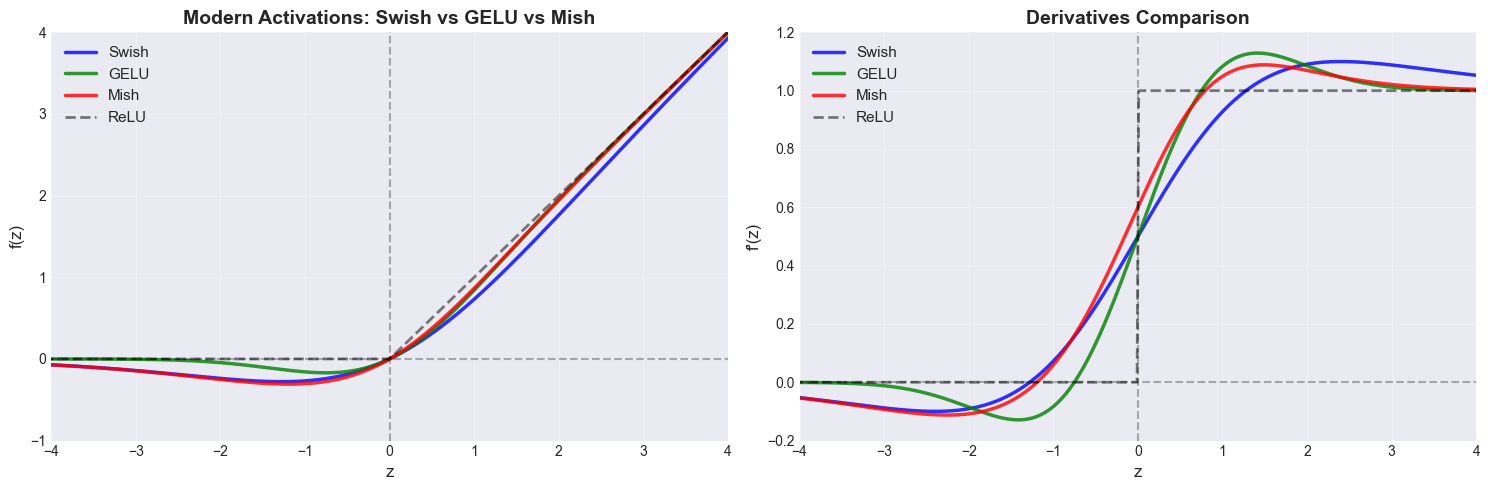

Modern Activations Comparison:
z        Swish        GELU         Mish         ReLU        
----------------------------------------------------------------------
-2.0     -0.2384      -0.0455      -0.2525      0.0000      
-1.0     -0.2689      -0.1587      -0.3034      0.0000      
0.0      0.0000       0.0000       0.0000       0.0000      
1.0      0.7311       0.8413       0.8651       1.0000      
2.0      1.7616       1.9545       1.9440       2.0000      


In [11]:
# Mish function
def softplus(z):
    """Softplus function (smooth ReLU)."""
    return np.log(1 + np.exp(np.clip(z, -500, 500)))

def mish(z):
    """Mish activation function."""
    return z * np.tanh(softplus(z))

def mish_derivative(z):
    """Derivative of Mish (approximate)."""
    omega = softplus(z)
    delta = sigmoid(z)
    tanh_omega = np.tanh(omega)
    return tanh_omega + z * delta * (1 - tanh_omega**2)

# Compare modern activations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Functions
ax1.plot(z, swish(z), 'b-', linewidth=2.5, label='Swish', alpha=0.8)
ax1.plot(z, gelu_exact(z), 'g-', linewidth=2.5, label='GELU', alpha=0.8)
ax1.plot(z, mish(z), 'r-', linewidth=2.5, label='Mish', alpha=0.8)
ax1.plot(z, relu(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('f(z)', fontsize=12)
ax1.set_title('Modern Activations: Swish vs GELU vs Mish', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xlim([-4, 4])
ax1.set_ylim([-1, 4])

# Derivatives
ax2.plot(z, swish_derivative(z), 'b-', linewidth=2.5, label='Swish', alpha=0.8)
ax2.plot(z, gelu_derivative(z), 'g-', linewidth=2.5, label='GELU', alpha=0.8)
ax2.plot(z, mish_derivative(z), 'r-', linewidth=2.5, label='Mish', alpha=0.8)
ax2.plot(z, relu_derivative(z), 'k--', linewidth=2, label='ReLU', alpha=0.5)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("f'(z)", fontsize=12)
ax2.set_title('Derivatives Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_xlim([-4, 4])
ax2.set_ylim([-0.2, 1.2])

plt.tight_layout()
plt.show()

print("Modern Activations Comparison:")
print("="*70)
z_test = np.array([-2, -1, 0, 1, 2])
print(f"{'z':<8} {'Swish':<12} {'GELU':<12} {'Mish':<12} {'ReLU':<12}")
print("-"*70)
for z_val in z_test:
    print(f"{z_val:<8.1f} {swish(z_val):<12.4f} {gelu_exact(z_val):<12.4f} "
          f"{mish(z_val):<12.4f} {relu(z_val):<12.4f}")
print("="*70)

<a id='advanced'></a>
## 5. Advanced Activation Functions

Cutting-edge research explores learnable and adaptive activations.

---

### 5.1 Hermite Polynomial Activations

**Concept:**

Use orthogonal polynomials (Hermite polynomials) to create flexible, learnable activations.

**Hermite Polynomials (probabilist's form):**

$$H_0(z) = 1$$
$$H_1(z) = z$$
$$H_2(z) = z^2 - 1$$
$$H_3(z) = z^3 - 3z$$
$$H_4(z) = z^4 - 6z^2 + 3$$

**General recurrence:**
$$H_{n+1}(z) = z H_n(z) - n H_{n-1}(z)$$

**Activation using Hermite polynomials:**

$$f_{\text{Hermite}}(z; \mathbf{a}) = \sum_{n=0}^{N} a_n H_n(z)$$

where $\mathbf{a} = [a_0, a_1, \ldots, a_N]$ are **learnable coefficients**.

**Weighted Hermite Activation:**

$$f(z) = \sum_{n=0}^{N} a_n H_n(z) \cdot e^{-z^2/2}$$

The Gaussian weight ensures the function is well-behaved.

**Derivatives:**

Since Hermite polynomials have closed-form derivatives:
$$H_n'(z) = n H_{n-1}(z)$$

The gradient is:
$$f'(z) = \sum_{n=1}^{N} a_n \cdot n H_{n-1}(z)$$

**Learning the coefficients:**

During backpropagation, we update $a_n$ based on:
$$\frac{\partial L}{\partial a_n} = \sum_{\text{batch}} \frac{\partial L}{\partial f(z)} \cdot H_n(z)$$

**Advantages:**
✅ **Highly flexible:** Can approximate any smooth function
✅ **Orthogonal basis:** Efficient representation
✅ **Learnable:** Adapts to the task
✅ **Theoretical foundation:** Strong mathematical basis

**Disadvantages:**
❌ Many parameters to learn
❌ Risk of overfitting
❌ Computational overhead

**Use Cases:**
- Research and experimentation
- When you need maximum flexibility
- Adaptive neural networks

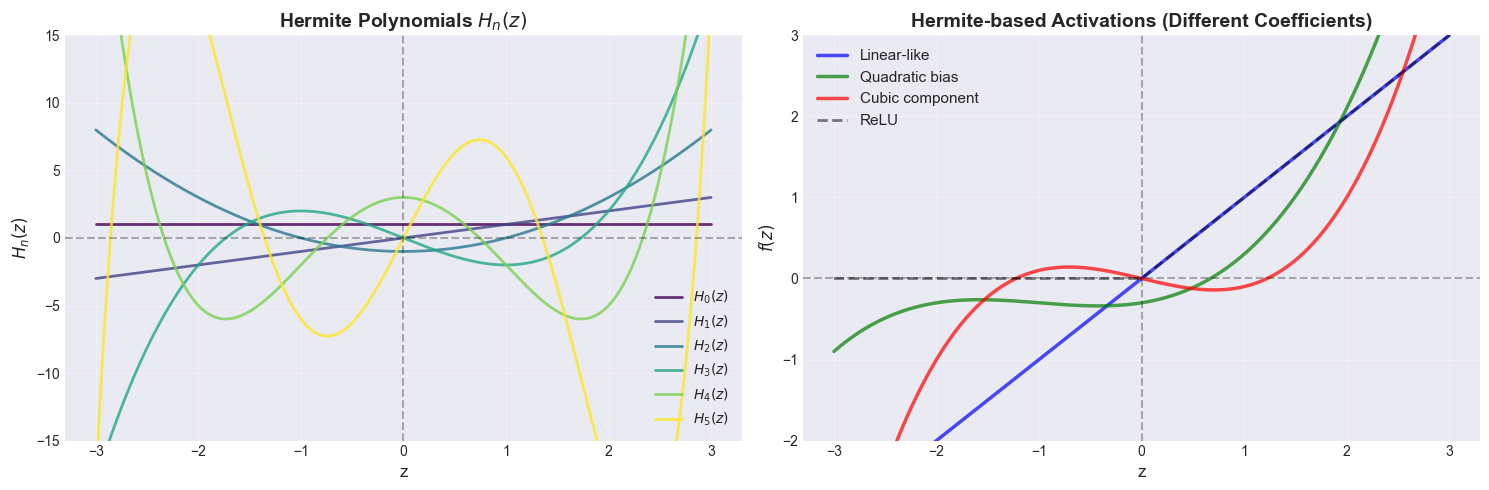

Hermite Activation Examples:

Linear-like:
  Coefficients: [0 1 0 0]

Quadratic bias:
  Coefficients: [0.  0.5 0.3 0.1]

Cubic component:
  Coefficients: [0.  0.3 0.  0.2]


In [12]:
# Hermite polynomials (probabilist's form)
def hermite_polynomial(n, z):
    """
    Compute Hermite polynomial H_n(z) using recurrence relation.
    
    H_0(z) = 1
    H_1(z) = z
    H_{n+1}(z) = z * H_n(z) - n * H_{n-1}(z)
    """
    if n == 0:
        return np.ones_like(z)
    elif n == 1:
        return z
    else:
        H_prev2 = np.ones_like(z)
        H_prev1 = z
        for k in range(1, n):
            H_current = z * H_prev1 - k * H_prev2
            H_prev2 = H_prev1
            H_prev1 = H_current
        return H_current

class HermiteActivation:
    """Learnable activation using Hermite polynomials."""
    
    def __init__(self, n_terms=5):
        """
        Initialize with random coefficients.
        
        Args:
            n_terms: Number of Hermite polynomial terms
        """
        self.n_terms = n_terms
        # Initialize with small random weights, bias towards ReLU-like
        self.coefficients = np.random.randn(n_terms) * 0.1
        self.coefficients[1] = 0.5  # Bias towards linear term
        
    def forward(self, z):
        """Compute activation."""
        self.z_cache = z
        result = np.zeros_like(z)
        for n in range(self.n_terms):
            result += self.coefficients[n] * hermite_polynomial(n, z)
        return result
    
    def derivative(self, z):
        """Compute derivative."""
        result = np.zeros_like(z)
        for n in range(1, self.n_terms):
            result += self.coefficients[n] * n * hermite_polynomial(n-1, z)
        return result

# Demonstrate Hermite polynomials
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot first few Hermite polynomials
ax1.set_title('Hermite Polynomials $H_n(z)$', fontsize=14, fontweight='bold')
colors = plt.cm.viridis(np.linspace(0, 1, 6))
z_hermite = np.linspace(-3, 3, 500)

for n in range(6):
    H_n = hermite_polynomial(n, z_hermite)
    ax1.plot(z_hermite, H_n, linewidth=2, label=f'$H_{n}(z)$', 
            color=colors[n], alpha=0.8)

ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('$H_n(z)$', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim([-15, 15])

# Create different Hermite activations with various coefficients
hermite_acts = [
    HermiteActivation(4),
    HermiteActivation(4),
    HermiteActivation(4)
]

# Set different coefficient patterns
hermite_acts[0].coefficients = np.array([0, 1, 0, 0])  # Linear
hermite_acts[1].coefficients = np.array([0, 0.5, 0.3, 0.1])  # Quadratic bias
hermite_acts[2].coefficients = np.array([0, 0.3, 0, 0.2])  # Cubic component

labels = ['Linear-like', 'Quadratic bias', 'Cubic component']
colors2 = ['blue', 'green', 'red']

for hermite, label, color in zip(hermite_acts, labels, colors2):
    ax2.plot(z_hermite, hermite.forward(z_hermite), linewidth=2.5, 
            label=label, color=color, alpha=0.7)

ax2.plot(z_hermite, relu(z_hermite), 'k--', linewidth=2, 
        label='ReLU', alpha=0.5)

ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel('$f(z)$', fontsize=12)
ax2.set_title('Hermite-based Activations (Different Coefficients)', 
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([-2, 3])

plt.tight_layout()
plt.show()

print("Hermite Activation Examples:")
print("="*70)
for i, (hermite, label) in enumerate(zip(hermite_acts, labels)):
    print(f"\n{label}:")
    print(f"  Coefficients: {hermite.coefficients}")

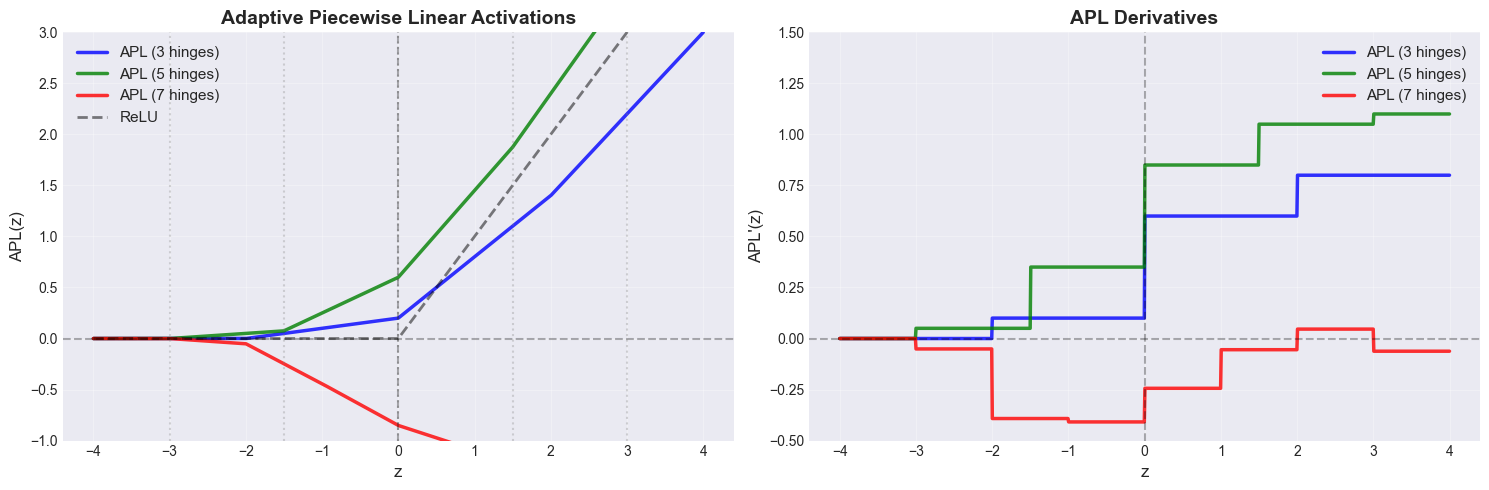

APL Characteristics:
- Piecewise linear: computationally efficient
- Learnable breakpoints: adapt to data
- Non-smooth: has kinks at breakpoints


In [13]:
class APLActivation:
    """Adaptive Piecewise Linear activation."""
    
    def __init__(self, n_hinges=5):
        """
        Initialize APL with random parameters.
        
        Args:
            n_hinges: Number of hinge functions
        """
        self.n_hinges = n_hinges
        # Initialize slopes and breakpoints
        self.slopes = np.random.randn(n_hinges) * 0.3
        self.breakpoints = np.linspace(-2, 2, n_hinges)
        
    def forward(self, z):
        """Compute APL activation."""
        result = np.zeros_like(z)
        for i in range(self.n_hinges):
            result += self.slopes[i] * np.maximum(0, z - self.breakpoints[i])
        return result
    
    def derivative(self, z):
        """Compute derivative."""
        result = np.zeros_like(z)
        for i in range(self.n_hinges):
            result += self.slopes[i] * (z > self.breakpoints[i]).astype(float)
        return result

# Demonstrate APL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Create APL activations with different configurations
apl1 = APLActivation(3)
apl1.slopes = np.array([0.1, 0.5, 0.2])
apl1.breakpoints = np.array([-2, 0, 2])

apl2 = APLActivation(5)
apl2.slopes = np.array([0.05, 0.3, 0.5, 0.2, 0.05])
apl2.breakpoints = np.linspace(-3, 3, 5)

apl3 = APLActivation(7)
apl3.slopes = np.random.randn(7) * 0.2
apl3.breakpoints = np.linspace(-3, 3, 7)

z_apl = np.linspace(-4, 4, 1000)

# Functions
ax1.plot(z_apl, apl1.forward(z_apl), 'b-', linewidth=2.5, 
        label='APL (3 hinges)', alpha=0.8)
ax1.plot(z_apl, apl2.forward(z_apl), 'g-', linewidth=2.5, 
        label='APL (5 hinges)', alpha=0.8)
ax1.plot(z_apl, apl3.forward(z_apl), 'r-', linewidth=2.5, 
        label='APL (7 hinges)', alpha=0.8)
ax1.plot(z_apl, relu(z_apl), 'k--', linewidth=2, label='ReLU', alpha=0.5)

# Mark breakpoints for apl2
for bp in apl2.breakpoints:
    ax1.axvline(x=bp, color='gray', linestyle=':', alpha=0.3)

ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('APL(z)', fontsize=12)
ax1.set_title('Adaptive Piecewise Linear Activations', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim([-1, 3])

# Derivatives
ax2.plot(z_apl, apl1.derivative(z_apl), 'b-', linewidth=2.5, 
        label='APL (3 hinges)', alpha=0.8)
ax2.plot(z_apl, apl2.derivative(z_apl), 'g-', linewidth=2.5, 
        label='APL (5 hinges)', alpha=0.8)
ax2.plot(z_apl, apl3.derivative(z_apl), 'r-', linewidth=2.5, 
        label='APL (7 hinges)', alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("APL'(z)", fontsize=12)
ax2.set_title('APL Derivatives', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([-0.5, 1.5])

plt.tight_layout()
plt.show()

print("APL Characteristics:")
print("- Piecewise linear: computationally efficient")
print("- Learnable breakpoints: adapt to data")
print("- Non-smooth: has kinks at breakpoints")

### 5.3 Parametric Activation Units (PAU)

**Concept:**

Learn a **rational function** (ratio of polynomials) as activation:

$$\text{PAU}(z) = \frac{P(z)}{Q(z)} = \frac{\sum_{i=0}^{m} p_i z^i}{\sum_{j=0}^{n} q_j z^j}$$

where $P$ and $Q$ are polynomials with learnable coefficients.

**Constraints:**
- Numerator degree $m$ typically 3-5
- Denominator degree $n$ typically 2-4
- $Q(z) > 0$ for all $z$ (enforce stability)

**Derivative:**

Using quotient rule:
$$\text{PAU}'(z) = \frac{P'(z)Q(z) - P(z)Q'(z)}{Q(z)^2}$$

**Safe PAU (ensuring positivity of denominator):**

$$Q(z) = 1 + \sum_{j=1}^{n} |q_j| z^{2j}$$

This ensures $Q(z) \geq 1 > 0$ for all $z$.

**Advantages:**
✅ **Universal approximator:** Rational functions can approximate any continuous function
✅ **Flexible:** Can model complex behaviors
✅ **Smooth:** Infinitely differentiable

**Disadvantages:**
❌ **Many parameters:** $(m+1) + (n+1)$ per activation
❌ **Numerical stability:** Division can be problematic
❌ **Complex training:** Requires careful initialization

**Use Cases:**
- Research on adaptive activations
- When maximum flexibility is needed
- Specialized domains with known functional forms

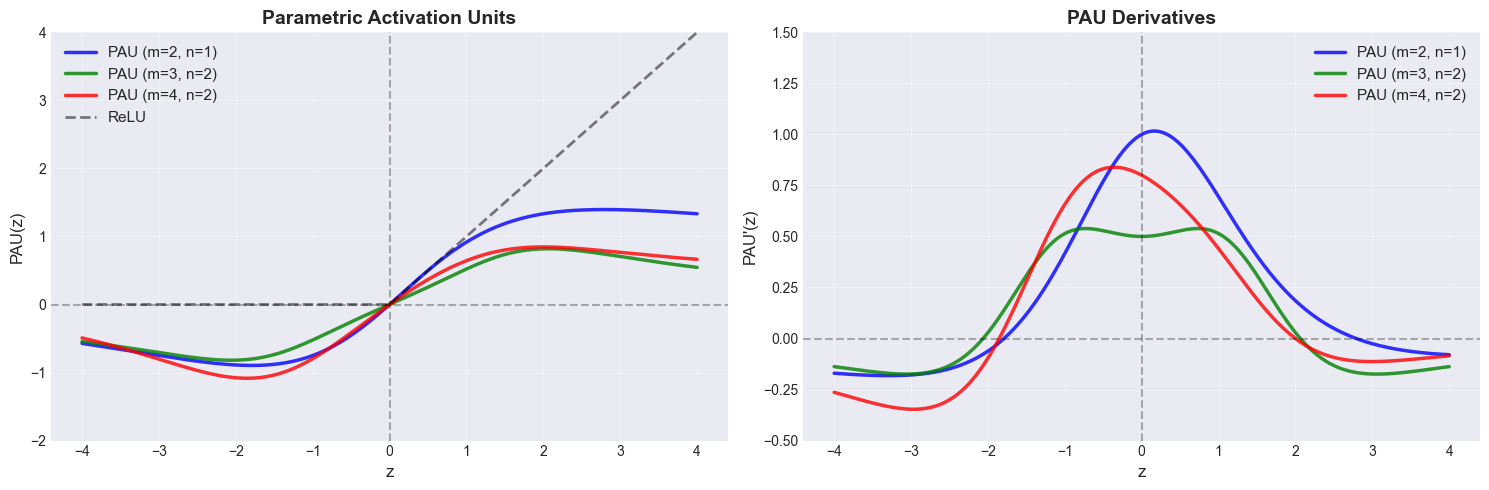

PAU Characteristics:
- Rational functions: P(z) / Q(z)
- Highly flexible and expressive
- Can approximate wide variety of shapes
- Requires careful initialization for stability


In [14]:
class PAU:
    """Parametric Activation Unit - rational function activation."""
    
    def __init__(self, numerator_degree=3, denominator_degree=2):
        """
        Initialize PAU.
        
        Args:
            numerator_degree: Degree of numerator polynomial
            denominator_degree: Degree of denominator polynomial
        """
        self.m = numerator_degree
        self.n = denominator_degree
        
        # Initialize coefficients (small random values)
        self.p = np.random.randn(numerator_degree + 1) * 0.1
        self.p[1] = 0.5  # Bias towards linear
        
        # Denominator: ensure positivity with squared terms
        self.q = np.abs(np.random.randn(denominator_degree + 1) * 0.1)
        self.q[0] = 1.0  # Constant term
        
    def _polynomial(self, z, coeffs):
        """Evaluate polynomial."""
        result = np.zeros_like(z)
        for i, c in enumerate(coeffs):
            result += c * (z ** i)
        return result
    
    def forward(self, z):
        """Compute PAU activation."""
        numerator = self._polynomial(z, self.p)
        # Use squared powers for denominator to ensure positivity
        denominator = 1.0
        for i in range(1, self.n + 1):
            denominator += np.abs(self.q[i]) * (z ** (2*i))
        
        # Add small epsilon for numerical stability
        return numerator / (denominator + 1e-8)
    
    def derivative(self, z):
        """Compute derivative (numerical for simplicity)."""
        eps = 1e-7
        return (self.forward(z + eps) - self.forward(z - eps)) / (2 * eps)

# Demonstrate PAU
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Create different PAU configurations
pau1 = PAU(numerator_degree=2, denominator_degree=1)
pau1.p = np.array([0, 1, 0.1])
pau1.q = np.array([1, 0.2])

pau2 = PAU(numerator_degree=3, denominator_degree=2)
pau2.p = np.array([0, 0.5, 0, 0.1])
pau2.q = np.array([1, 0.1, 0.05])

pau3 = PAU(numerator_degree=4, denominator_degree=2)
pau3.p = np.array([0, 0.8, -0.1, 0.05, 0.01])
pau3.q = np.array([1, 0.15, 0.03])

z_pau = np.linspace(-4, 4, 1000)

# Functions
ax1.plot(z_pau, pau1.forward(z_pau), 'b-', linewidth=2.5, 
        label='PAU (m=2, n=1)', alpha=0.8)
ax1.plot(z_pau, pau2.forward(z_pau), 'g-', linewidth=2.5, 
        label='PAU (m=3, n=2)', alpha=0.8)
ax1.plot(z_pau, pau3.forward(z_pau), 'r-', linewidth=2.5, 
        label='PAU (m=4, n=2)', alpha=0.8)
ax1.plot(z_pau, relu(z_pau), 'k--', linewidth=2, label='ReLU', alpha=0.5)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('PAU(z)', fontsize=12)
ax1.set_title('Parametric Activation Units', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim([-2, 4])

# Derivatives
ax2.plot(z_pau, pau1.derivative(z_pau), 'b-', linewidth=2.5, 
        label='PAU (m=2, n=1)', alpha=0.8)
ax2.plot(z_pau, pau2.derivative(z_pau), 'g-', linewidth=2.5, 
        label='PAU (m=3, n=2)', alpha=0.8)
ax2.plot(z_pau, pau3.derivative(z_pau), 'r-', linewidth=2.5, 
        label='PAU (m=4, n=2)', alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel("PAU'(z)", fontsize=12)
ax2.set_title('PAU Derivatives', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([-0.5, 1.5])

plt.tight_layout()
plt.show()

print("PAU Characteristics:")
print("- Rational functions: P(z) / Q(z)")
print("- Highly flexible and expressive")
print("- Can approximate wide variety of shapes")
print("- Requires careful initialization for stability")

<a id='comparison'></a>
## 6. Comparative Analysis

### 6.1 Visual Comparison: All Activations

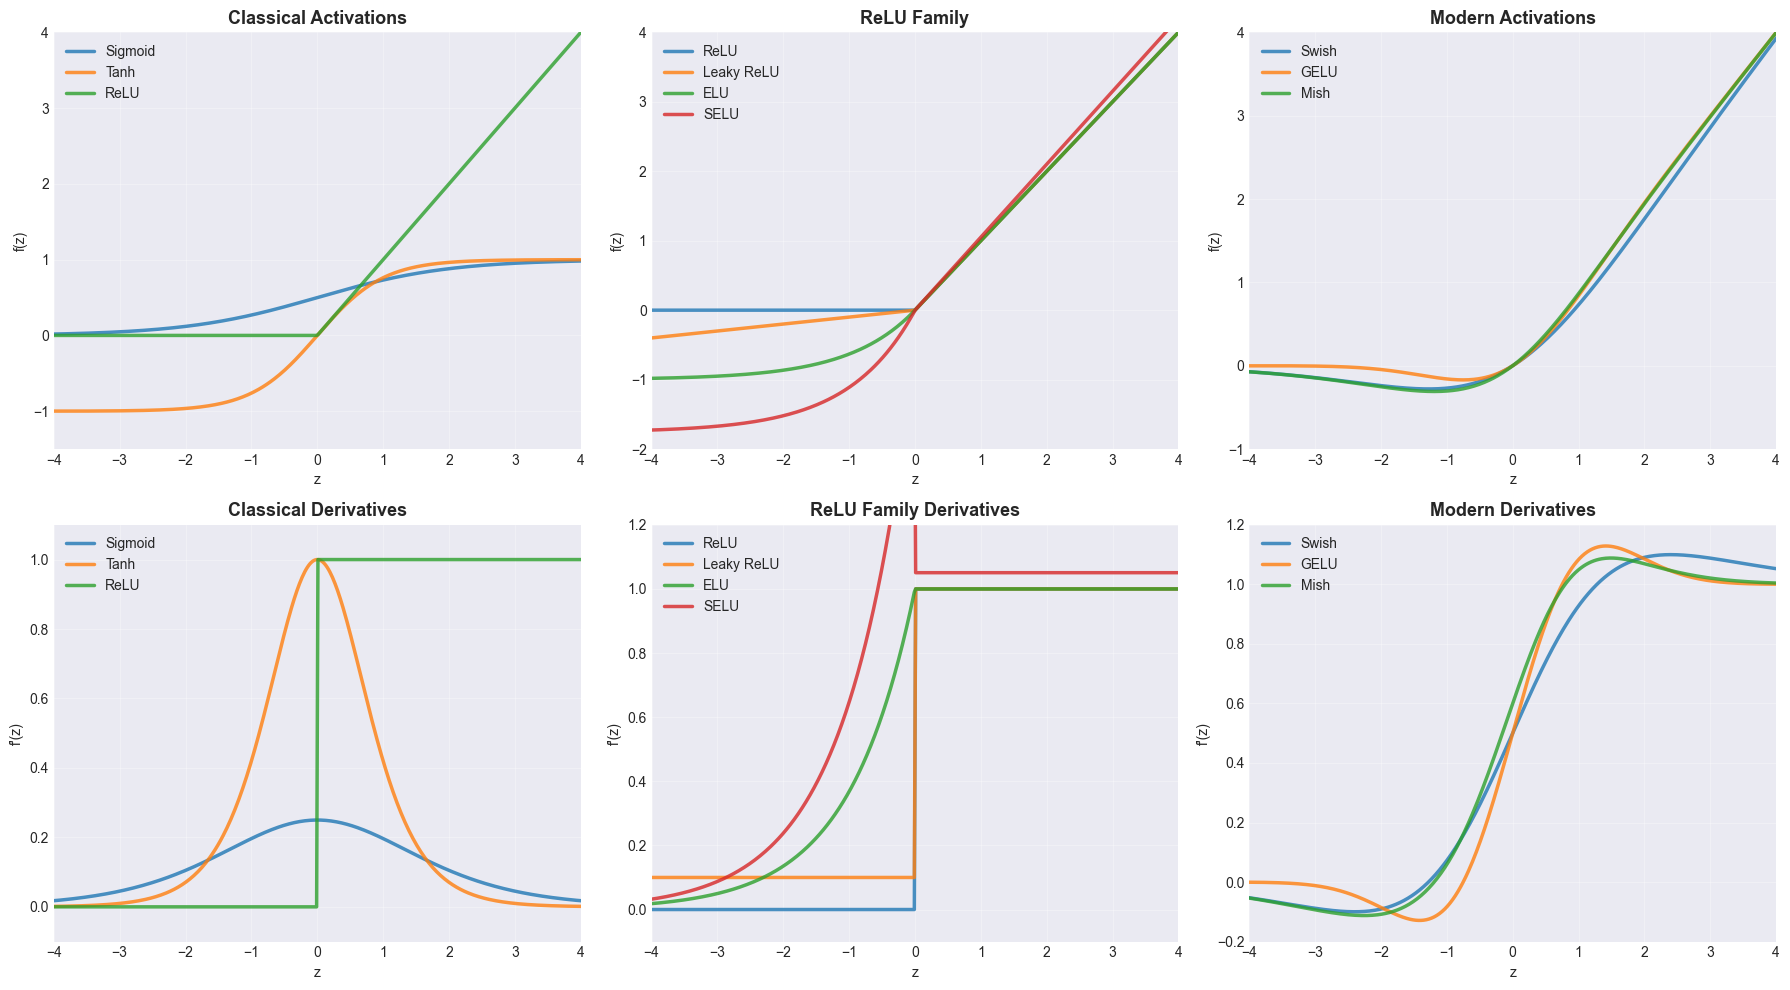

In [15]:
# Create comprehensive comparison
fig = plt.figure(figsize=(18, 10))

# Classical
ax1 = plt.subplot(2, 3, 1)
ax1.plot(z, sigmoid(z), linewidth=2.5, label='Sigmoid', alpha=0.8)
ax1.plot(z, tanh(z), linewidth=2.5, label='Tanh', alpha=0.8)
ax1.plot(z, relu(z), linewidth=2.5, label='ReLU', alpha=0.8)
ax1.set_title('Classical Activations', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-4, 4])
ax1.set_ylim([-1.5, 4])
ax1.set_xlabel('z')
ax1.set_ylabel('f(z)')

# ReLU variants
ax2 = plt.subplot(2, 3, 2)
ax2.plot(z, relu(z), linewidth=2.5, label='ReLU', alpha=0.8)
ax2.plot(z, leaky_relu(z, 0.1), linewidth=2.5, label='Leaky ReLU', alpha=0.8)
ax2.plot(z, elu(z, 1.0), linewidth=2.5, label='ELU', alpha=0.8)
ax2.plot(z, selu(z), linewidth=2.5, label='SELU', alpha=0.8)
ax2.set_title('ReLU Family', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([-4, 4])
ax2.set_ylim([-2, 4])
ax2.set_xlabel('z')
ax2.set_ylabel('f(z)')

# Modern
ax3 = plt.subplot(2, 3, 3)
ax3.plot(z, swish(z), linewidth=2.5, label='Swish', alpha=0.8)
ax3.plot(z, gelu_exact(z), linewidth=2.5, label='GELU', alpha=0.8)
ax3.plot(z, mish(z), linewidth=2.5, label='Mish', alpha=0.8)
ax3.set_title('Modern Activations', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([-4, 4])
ax3.set_ylim([-1, 4])
ax3.set_xlabel('z')
ax3.set_ylabel('f(z)')

# Derivatives: Classical
ax4 = plt.subplot(2, 3, 4)
ax4.plot(z, sigmoid_derivative(z), linewidth=2.5, label='Sigmoid', alpha=0.8)
ax4.plot(z, tanh_derivative(z), linewidth=2.5, label='Tanh', alpha=0.8)
ax4.plot(z, relu_derivative(z), linewidth=2.5, label='ReLU', alpha=0.8)
ax4.set_title('Classical Derivatives', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim([-4, 4])
ax4.set_ylim([-0.1, 1.1])
ax4.set_xlabel('z')
ax4.set_ylabel("f'(z)")

# Derivatives: ReLU variants
ax5 = plt.subplot(2, 3, 5)
ax5.plot(z, relu_derivative(z), linewidth=2.5, label='ReLU', alpha=0.8)
ax5.plot(z, leaky_relu_derivative(z, 0.1), linewidth=2.5, label='Leaky ReLU', alpha=0.8)
ax5.plot(z, elu_derivative(z, 1.0), linewidth=2.5, label='ELU', alpha=0.8)
ax5.plot(z, selu_derivative(z), linewidth=2.5, label='SELU', alpha=0.8)
ax5.set_title('ReLU Family Derivatives', fontsize=13, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_xlim([-4, 4])
ax5.set_ylim([-0.1, 1.2])
ax5.set_xlabel('z')
ax5.set_ylabel("f'(z)")

# Derivatives: Modern
ax6 = plt.subplot(2, 3, 6)
ax6.plot(z, swish_derivative(z), linewidth=2.5, label='Swish', alpha=0.8)
ax6.plot(z, gelu_derivative(z), linewidth=2.5, label='GELU', alpha=0.8)
ax6.plot(z, mish_derivative(z), linewidth=2.5, label='Mish', alpha=0.8)
ax6.set_title('Modern Derivatives', fontsize=13, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_xlim([-4, 4])
ax6.set_ylim([-0.2, 1.2])
ax6.set_xlabel('z')
ax6.set_ylabel("f'(z)")

plt.tight_layout()
plt.show()

### 6.2 Detailed Comparison Table

In [16]:
import pandas as pd

# Create comprehensive comparison table
comparison_data = {
    'Activation': [
        'Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU', 'ELU', 'SELU',
        'Swish', 'GELU', 'Mish'
    ],
    'Range': [
        '(0, 1)', '(-1, 1)', '[0, ∞)', '(-∞, ∞)', '(-α, ∞)', '(-λα, ∞)',
        '(-0.28, ∞)', '(-0.17, ∞)', '(-0.31, ∞)'
    ],
    'Zero-Centered': [
        'No', 'Yes', 'No', 'No', 'No', 'No',
        'No', 'No', 'No'
    ],
    'Smooth': [
        'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes'
    ],
    'Monotonic': [
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'No', 'No', 'No'
    ],
    'Vanishing Gradient': [
        'Yes', 'Yes', 'No (z>0)', 'No', 'Minimal', 'Minimal',
        'Minimal', 'Minimal', 'Minimal'
    ],
    'Computational Cost': [
        'High', 'High', 'Low', 'Low', 'Medium', 'Medium',
        'Medium', 'High', 'High'
    ],
    'Typical Use': [
        'Output', 'RNN', 'Default', 'Deep nets', 'Research', 'Dense nets',
        'Vision', 'Transformers', 'Vision/GANs'
    ]
}

df = pd.DataFrame(comparison_data)

# Display styled table
print("\n" + "="*120)
print("COMPREHENSIVE ACTIVATION FUNCTION COMPARISON")
print("="*120)
print(df.to_string(index=False))
print("="*120)

# Performance characteristics
print("\n\nPERFORMANCE CHARACTERISTICS")
print("="*100)
print(f"{'Activation':<15} {'Speed':<10} {'Memory':<10} {'Gradient Flow':<20} {'Training Stability':<20}")
print("-"*100)

performance = [
    ('Sigmoid', 'Slow', 'Low', 'Poor (vanishing)', 'Moderate'),
    ('Tanh', 'Slow', 'Low', 'Fair (vanishing)', 'Good'),
    ('ReLU', 'Fast', 'Low', 'Good (z>0)', 'Good'),
    ('Leaky ReLU', 'Fast', 'Low', 'Good', 'Good'),
    ('ELU', 'Medium', 'Low', 'Very Good', 'Very Good'),
    ('SELU', 'Medium', 'Low', 'Excellent', 'Excellent'),
    ('Swish', 'Medium', 'Low', 'Excellent', 'Very Good'),
    ('GELU', 'Slow', 'Low', 'Excellent', 'Excellent'),
    ('Mish', 'Slow', 'Low', 'Excellent', 'Excellent'),
]

for row in performance:
    print(f"{row[0]:<15} {row[1]:<10} {row[2]:<10} {row[3]:<20} {row[4]:<20}")
print("="*100)


COMPREHENSIVE ACTIVATION FUNCTION COMPARISON
Activation      Range Zero-Centered Smooth Monotonic Vanishing Gradient Computational Cost  Typical Use
   Sigmoid     (0, 1)            No    Yes       Yes                Yes               High       Output
      Tanh    (-1, 1)           Yes    Yes       Yes                Yes               High          RNN
      ReLU     [0, ∞)            No     No       Yes           No (z>0)                Low      Default
Leaky ReLU    (-∞, ∞)            No     No       Yes                 No                Low    Deep nets
       ELU    (-α, ∞)            No    Yes       Yes            Minimal             Medium     Research
      SELU   (-λα, ∞)            No    Yes       Yes            Minimal             Medium   Dense nets
     Swish (-0.28, ∞)            No    Yes        No            Minimal             Medium       Vision
      GELU (-0.17, ∞)            No    Yes        No            Minimal               High Transformers
      Mish (-0.31,

### 6.3 Empirical Testing: Classification Task

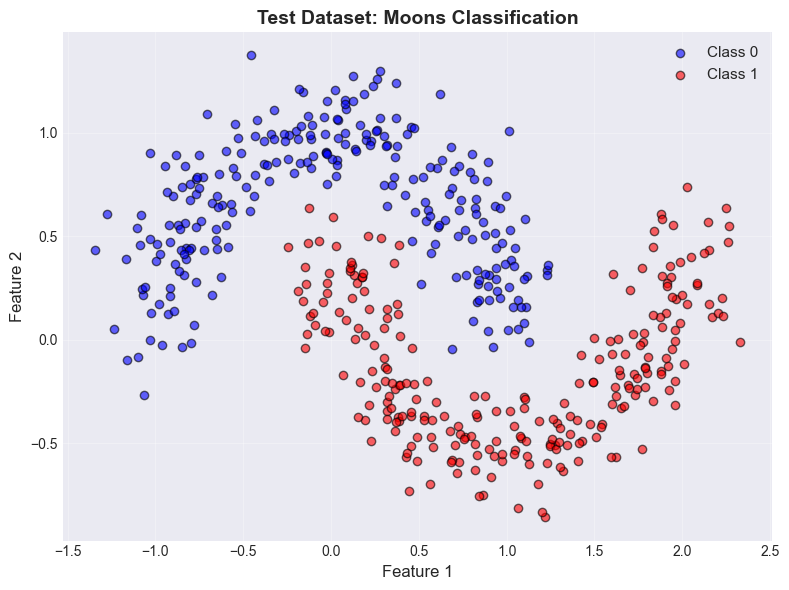

Dataset: 500 samples, 2 features
Classes: [0 1]


In [17]:
# Simple empirical test: 2D spiral classification
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate data
np.random.seed(42)
X_data, y_data = make_moons(n_samples=500, noise=0.15, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_data[y_data == 0, 0], X_data[y_data == 0, 1], 
           c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_data[y_data == 1, 0], X_data[y_data == 1, 1], 
           c='red', label='Class 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Test Dataset: Moons Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dataset: {X_data.shape[0]} samples, {X_data.shape[1]} features")
print(f"Classes: {np.unique(y_data)}")

In [ ]:
# Binary cross-entropy loss function
def binary_cross_entropy(y_true, y_pred):
    """
    Binary cross-entropy loss.
    
    Args:
        y_true: True labels (n_samples,)
        y_pred: Predicted probabilities (n_samples,)
    
    Returns:
        Scalar loss value
    """
    epsilon = 1e-15  # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [18]:
# Simple neural network for testing
class SimpleNN:
    """Simple 2-layer NN for testing activations."""
    
    def __init__(self, activation_fn, activation_derivative, hidden_size=10):
        self.activation = activation_fn
        self.activation_derivative = activation_derivative
        
        # Initialize weights
        self.W1 = np.random.randn(2, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * 0.5
        self.b2 = np.zeros((1, 1))
        
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.activation(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2
    
    def train(self, X, y, epochs=500, lr=0.1, verbose=False):
        losses = []
        y = y.reshape(-1, 1)
        
        for epoch in range(epochs):
            # Forward
            output = self.forward(X)
            loss = binary_cross_entropy(y.flatten(), output.flatten())
            losses.append(loss)
            
            # Backward
            dz2 = output - y
            dW2 = self.a1.T @ dz2 / len(X)
            db2 = np.mean(dz2, axis=0, keepdims=True)
            
            da1 = dz2 @ self.W2.T
            dz1 = da1 * self.activation_derivative(self.z1)
            dW1 = X.T @ dz1 / len(X)
            db1 = np.mean(dz1, axis=0, keepdims=True)
            
            # Update
            self.W2 -= lr * dW2
            self.b2 -= lr * db2
            self.W1 -= lr * dW1
            self.b1 -= lr * db1
        
        return losses
    
    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int).flatten()
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Test different activations
activations_to_test = [
    ('ReLU', relu, relu_derivative),
    ('Tanh', tanh, tanh_derivative),
    ('ELU', lambda z: elu(z, 1.0), lambda z: elu_derivative(z, 1.0)),
    ('Swish', swish, swish_derivative),
]

results = {}

print("Training neural networks with different activations...")
print("="*70)

for name, act_fn, act_deriv in activations_to_test:
    np.random.seed(42)
    nn = SimpleNN(act_fn, act_deriv, hidden_size=20)
    losses = nn.train(X_data, y_data, epochs=1000, lr=0.5, verbose=False)
    accuracy = nn.score(X_data, y_data)
    results[name] = {'losses': losses, 'accuracy': accuracy, 'model': nn}
    print(f"{name:<15} Final Loss: {losses[-1]:.4f}  Accuracy: {accuracy:.4f}")

print("="*70)

Training neural networks with different activations...


NameError: name 'binary_cross_entropy' is not defined

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for name, data in results.items():
    ax1.plot(data['losses'], linewidth=2, label=name, alpha=0.8)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Bar plot of final accuracy
names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in names]

bars = ax2.bar(names, accuracies, alpha=0.7, edgecolor='black', linewidth=1.5)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(names)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Final Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim([0.8, 1.0])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (name, acc) in enumerate(zip(names, accuracies)):
    ax2.text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<a id='use-cases'></a>
## 7. Use Cases & Best Practices

### When to Use Which Activation?

---

### 7.1 Decision Tree for Activation Selection

```
START
│
├─ Output Layer?
│  ├─ Binary Classification → Sigmoid
│  ├─ Multi-class Classification → Softmax
│  ├─ Regression (bounded) → Sigmoid/Tanh
│  └─ Regression (unbounded) → Linear/None
│
└─ Hidden Layer?
   │
   ├─ Default/Starting Point → ReLU
   │
   ├─ Dying ReLU Problem?
   │  ├─ Simple fix → Leaky ReLU (α=0.01)
   │  ├─ Learn the slope → PReLU
   │  └─ Smooth alternative → ELU/SELU
   │
   ├─ Network Type?
   │  ├─ Convolutional (CNN) → ReLU, Swish, or Mish
   │  ├─ Recurrent (RNN/LSTM) → Tanh (gates), Sigmoid (gates)
   │  ├─ Transformer → GELU
   │  ├─ Deep Fully-Connected → SELU (with proper init)
   │  └─ GAN → Leaky ReLU, Mish
   │
   ├─ Performance Critical?
   │  ├─ Speed Priority → ReLU
   │  ├─ Accuracy Priority → Swish, GELU, Mish
   │  └─ Balance → ELU, Leaky ReLU
   │
   └─ Special Requirements?
      ├─ Self-normalizing → SELU
      ├─ Maximum smoothness → ELU, Swish, Mish
      ├─ Avoid BatchNorm → SELU
      └─ State-of-the-art → GELU (NLP), Swish (Vision)
```

### 7.2 Domain-Specific Recommendations

#### Computer Vision (CNNs)
**Recommended:** ReLU, Swish, Mish

**Reasoning:**
- **ReLU**: Default, fast, works well in most cases
- **Swish**: Better than ReLU on ImageNet (used in EfficientNet)
- **Mish**: Strong performance on object detection

**Architecture examples:**
- ResNet: ReLU
- EfficientNet: Swish
- YOLOv4: Mish

---

#### Natural Language Processing (Transformers)
**Recommended:** GELU

**Reasoning:**
- Used in BERT, GPT-2, GPT-3, T5
- Smooth with probabilistic interpretation
- Empirically superior for language tasks

**Architecture examples:**
- BERT: GELU
- GPT-3: GELU
- T5: GELU

---

#### Recurrent Neural Networks
**Recommended:** Tanh (hidden), Sigmoid (gates)

**Reasoning:**
- Tanh is zero-centered (helps with RNN training)
- Sigmoid for gates (range 0-1 for gating)
- LSTM/GRU designed with these activations

---

#### Generative Adversarial Networks
**Recommended:** Leaky ReLU, Mish

**Reasoning:**
- Leaky ReLU prevents dying neurons (critical in GANs)
- Allows gradient flow for both positive and negative values
- Mish shown to improve stability

---

#### Deep Fully-Connected Networks
**Recommended:** SELU, ELU

**Reasoning:**
- SELU provides self-normalization
- ELU gives smooth gradients
- Both reduce vanishing gradient problem

**Requirements for SELU:**
- LeCun Normal initialization
- Sequential/AlphaDropout (not standard dropout)
- Fully-connected architecture

### 7.3 Common Pitfalls and Solutions

#### Problem 1: Dying ReLU
**Symptoms:** 
- Many neurons always output 0
- Loss stops decreasing
- Large negative bias values

**Solutions:**
1. Use Leaky ReLU or PReLU
2. Reduce learning rate
3. Better weight initialization (He initialization)
4. Use ELU or SELU

---

#### Problem 2: Vanishing Gradients
**Symptoms:**
- Very deep networks fail to train
- Earlier layers have tiny gradients
- Loss barely changes

**Solutions:**
1. Replace Sigmoid/Tanh with ReLU variants
2. Use residual connections (ResNet)
3. Use SELU for self-normalization
4. Batch normalization
5. Better initialization

---

#### Problem 3: Exploding Activations
**Symptoms:**
- Activations become very large (NaN)
- Training unstable
- Loss oscillates wildly

**Solutions:**
1. Reduce learning rate
2. Use activation with saturation (Sigmoid, Tanh)
3. Gradient clipping
4. Batch normalization
5. Better weight initialization

---

#### Problem 4: Slow Convergence
**Symptoms:**
- Training takes very long
- Loss decreases slowly

**Solutions:**
1. Try Swish or GELU (often faster convergence)
2. Use SELU with proper initialization
3. Increase learning rate (carefully)
4. Use adaptive optimizers (Adam)
5. Batch normalization

### 7.4 Initialization Guidelines

Different activations require different initialization schemes:

**ReLU / Leaky ReLU / PReLU:**
$$W \sim \text{Normal}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

**Implementation:**
```python
W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)  # He initialization
```

**Sigmoid / Tanh:**
$$W \sim \text{Uniform}\left(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right)$$

**Implementation:**
```python
limit = np.sqrt(6.0 / (n_in + n_out))
W = np.random.uniform(-limit, limit, (n_in, n_out))  # Xavier initialization
```

**SELU:**
$$W \sim \text{Normal}\left(0, \sqrt{\frac{1}{n_{in}}}\right)$$

**Implementation:**
```python
W = np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)  # LeCun initialization
```

**Swish / GELU / Mish:**
Use He initialization (same as ReLU)

In [ ]:
# Demonstrate proper initialization
def initialize_weights(n_in, n_out, activation='relu'):
    """
    Initialize weights based on activation function.
    
    Args:
        n_in: Input dimension
        n_out: Output dimension
        activation: Type of activation ('relu', 'tanh', 'selu')
    
    Returns:
        Initialized weight matrix
    """
    if activation in ['relu', 'leaky_relu', 'prelu', 'elu', 'swish', 'gelu', 'mish']:
        # He initialization
        return np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
    
    elif activation in ['sigmoid', 'tanh']:
        # Xavier initialization
        limit = np.sqrt(6.0 / (n_in + n_out))
        return np.random.uniform(-limit, limit, (n_in, n_out))
    
    elif activation == 'selu':
        # LeCun initialization
        return np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)
    
    else:
        raise ValueError(f"Unknown activation: {activation}")

# Test initialization variance
n_in, n_out = 100, 50
activations = ['relu', 'tanh', 'selu']

print("Weight Initialization Statistics")
print("="*60)
print(f"{'Activation':<15} {'Method':<15} {'Mean':<12} {'Std Dev':<12}")
print("-"*60)

for act in activations:
    W = initialize_weights(n_in, n_out, act)
    method = {'relu': 'He', 'tanh': 'Xavier', 'selu': 'LeCun'}[act]
    print(f"{act:<15} {method:<15} {np.mean(W):<12.6f} {np.std(W):<12.6f}")

print("="*60)

# Visualize initialization distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, act in zip(axes, activations):
    W = initialize_weights(n_in, n_out, act)
    ax.hist(W.flatten(), bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'{act.upper()}\n({["He", "Xavier", "LeCun"][activations.index(act)]} init)', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<a id='summary'></a>
## 8. Summary

---

### Key Takeaways

#### 1. **Classical Activations (Historical Foundation)**
- **Sigmoid**: Bounded (0,1), vanishing gradients, use for output layers
- **Tanh**: Bounded (-1,1), zero-centered, better than sigmoid for hidden layers
- **ReLU**: Fast, effective, but can "die" - still the default choice

#### 2. **ReLU Family (Addressing Limitations)**
- **Leaky ReLU**: Prevents dying neurons with small negative slope
- **PReLU**: Learns optimal negative slope
- **ELU**: Smooth, reduces bias shift, good for deep networks
- **SELU**: Self-normalizing, use with LeCun init in dense networks

#### 3. **Modern Activations (State-of-the-Art)**
- **Swish**: Smooth, non-monotonic, excellent for CNNs (EfficientNet)
- **GELU**: Probabilistic, smooth, standard in Transformers (BERT, GPT)
- **Mish**: Similar to Swish, strong empirical performance

#### 4. **Advanced/Learnable (Research Frontier)**
- **Hermite**: Flexible polynomial basis, many parameters
- **APL**: Piecewise linear, efficient and adaptive
- **PAU**: Rational functions, maximum flexibility

---

### Quick Reference Table

| Task | First Choice | Alternative | Avoid |
|------|--------------|-------------|-------|
| CNN Hidden Layers | ReLU | Swish, Mish | Sigmoid |
| Transformer | GELU | Swish | ReLU |
| RNN/LSTM Gates | Sigmoid, Tanh | - | ReLU |
| Deep FC Networks | SELU | ELU | Sigmoid |
| GAN | Leaky ReLU | Mish | ReLU |
| Binary Output | Sigmoid | - | ReLU |
| Regression Output | Linear | - | Sigmoid |

---

### Best Practices Summary

1. **Start with ReLU** for hidden layers in most architectures
2. **Use appropriate initialization** (He for ReLU, Xavier for Tanh, LeCun for SELU)
3. **Switch to modern activations** (Swish, GELU) for maximum performance
4. **Fix dying ReLU** with Leaky ReLU or ELU
5. **Match architecture to task** (GELU for Transformers, ReLU for CNNs)
6. **Consider computational cost** (ReLU fastest, GELU slower)
7. **Experiment!** Different tasks may benefit from different activations

---

### Future Directions

- **Learned activations**: Networks that learn optimal activation shapes
- **Mixture of activations**: Different activations for different neurons
- **Task-specific activations**: Custom designs for specific domains
- **Hardware-aware activations**: Optimized for specific accelerators

---

## 🎉 Conclusion

You now have a comprehensive understanding of activation functions from first principles:
- **Mathematical foundations** and derivations
- **Classical to modern** activations
- **Practical implementation** and usage
- **When and why** to use each one

**Remember:** The activation function is a crucial design choice, but it's just one part of the puzzle. Architecture, initialization, optimization, and data all matter too!

Happy deep learning! 🚀

In [ ]:
# Hermite polynomials (probabilist's form)
def hermite_polynomial(n, z):
    """
    Compute Hermite polynomial H_n(z) using recurrence relation.
    
    H_0(z) = 1
    H_1(z) = z
    H_{n+1}(z) = z * H_n(z) - n * H_{n-1}(z)
    """
    if n == 0:
        return np.ones_like(z)
    elif n == 1:
        return z
    else:
        H_prev2 = np.ones_like(z)
        H_prev1 = z
        for k in range(1, n):
            H_current = z * H_prev1 - k * H_prev2
            H_prev2 = H_prev1
            H_prev1 = H_current
        return H_current

class HermiteActivation:
    """Learnable activation using Hermite polynomials."""
    
    def __init__(self, n_terms=5):
        """
        Initialize with random coefficients.
        
        Args:
            n_terms: Number of Hermite polynomial terms
        """
        self.n_terms = n_terms
        # Initialize with small random weights, bias towards ReLU-like
        self.coefficients = np.random.randn(n_terms) * 0.1
        self.coefficients[1] = 0.5  # Bias towards linear term
        
    def forward(self, z):
        """Compute activation."""
        self.z_cache = z
        result = np.zeros_like(z)
        for n in range(self.n_terms):
            result += self.coefficients[n] * hermite_polynomial(n, z)
        return result
    
    def derivative(self, z):
        """Compute derivative."""
        result = np.zeros_like(z)
        for n in range(1, self.n_terms):
            result += self.coefficients[n] * n * hermite_polynomial(n-1, z)
        return result

# Demonstrate Hermite polynomials
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot first few Hermite polynomials
ax1.set_title('Hermite Polynomials $H_n(z)$', fontsize=14, fontweight='bold')
colors = plt.cm.viridis(np.linspace(0, 1, 6))
z_hermite = np.linspace(-3, 3, 500)

for n in range(6):
    H_n = hermite_polynomial(n, z_hermite)
    ax1.plot(z_hermite, H_n, linewidth=2, label=f'$H_{n}(z)$', 
            color=colors[n], alpha=0.8)

ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('$H_n(z)$', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim([-15, 15])

# Create different Hermite activations with various coefficients
hermite_acts = [
    HermiteActivation(4),
    HermiteActivation(4),
    HermiteActivation(4)
]

# Set different coefficient patterns
hermite_acts[0].coefficients = np.array([0, 1, 0, 0])  # Linear
hermite_acts[1].coefficients = np.array([0, 0.5, 0.3, 0.1])  # Quadratic bias
hermite_acts[2].coefficients = np.array([0, 0.3, 0, 0.2])  # Cubic component

labels = ['Linear-like', 'Quadratic bias', 'Cubic component']
colors2 = ['blue', 'green', 'red']

for hermite, label, color in zip(hermite_acts, labels, colors2):
    ax2.plot(z_hermite, hermite.forward(z_hermite), linewidth=2.5, 
            label=label, color=color, alpha=0.7)

ax2.plot(z_hermite, relu(z_hermite), 'k--', linewidth=2, 
        label='ReLU', alpha=0.5)

ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel('$f(z)$', fontsize=12)
ax2.set_title('Hermite-based Activations (Different Coefficients)', 
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([-2, 3])

plt.tight_layout()
plt.show()

print("Hermite Activation Examples:")
print("="*70)
for i, (hermite, label) in enumerate(zip(hermite_acts, labels)):
    print(f"\n{label}:")
    print(f"  Coefficients: {hermite.coefficients}")